# 신용카드 채무불이행 고객 예측 

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [1]:
!pip install xlrd --break-system-packages


In [2]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)
print(df.shape)

# df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [3]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)


# 프로세스

신용카드 채무불이행 예측 모델링 프로세스

전체 단계
1. EDA - 타깃 분포, 결측치, 피처 분포 확인                        
2. 데이터 전처리 - 인코딩, 스케일링, 불필요 컬럼 제거
3. Train/Test Split - stratify 옵션으로 클래스 비율 유지
4. 모델 학습 - Logistic Regression, RandomForest, XGBoost  비교
5. 모델 평가 - Accuracy, Precision, Recall, F1, ROC-AUC
6. 피처 중요도 - 어떤 변수가 예측에 영향을 주는지 시각화
7. (선택) 하이퍼파라미터 튜닝 - GridSearchCV 또는 RandomizedSearchCV


모델링 프로세스 요약

Target : default (0 = 정상, 1 = 채무불이행)

1단계 EDA
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치 · 이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

2단계 데이터 전처리
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

3단계 Train / Test Split
- train_test_split — stratify=y 옵션으로 클래스 비율 유지
- 일반적으로 80 : 20 분할

4단계 모델 학습
- Logistic Regression (베이스라인)
- Random Forest
- XGBoost

5단계 모델 평가
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve — 불균형 데이터에서 특히 중요

6단계 피처 중요도
- 트리 기반 모델의 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

7단계 하이퍼파라미터 튜닝 (선택)
- GridSearchCV 또는 RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습



# 1 EDA

In [4]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [5]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")

=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


분석 결과

정상(0) : 23,364명 (77.9%)
채무불이행(1) : 6,636명 (22.1%)
비율 약 4 : 1 → 클래스 불균형(Class Imbalance) 존재

모델링 시 주의사항

Accuracy 만으로는 평가 불충분 → 모델이 전부 0으로 예측해도 77.9% 달성 가능
Recall, F1-Score, ROC-AUC 를 주요 평가 지표로 사용
채무불이행(소수 클래스)을 놓치는 것이 비즈니스 손실이 크므로 Recall 이 특히 중요
필요 시 class_weight='balanced' 또는 오버샘플링(SMOTE) 적용 고려

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [7]:
# ============================================================
# Step 1: EDA - 타깃 분포, 결측치, 피처 분포 확인
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ──────────────────────────────────────────────
df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df = card_df.rename(columns={'default payment next month': 'default'})

print("=" * 55)
print("▶ 1-1. 데이터 기본 정보")
print("=" * 55)
print(f"데이터 크기: {card_df.shape}")
print(f"\n컬럼 목록:\n{card_df.columns.tolist()}")
print()
card_df.info()

▶ 1-1. 데이터 기본 정보
데이터 크기: (30000, 24)

컬럼 목록:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30

In [8]:
# ── 1-2. 결측치 확인 ─────────────────────────────────────────
print("=" * 55)
print("▶ 1-2. 결측치 확인")
print("=" * 55)
missing = card_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ 결측치 없음")

▶ 1-2. 결측치 확인
✅ 결측치 없음


In [9]:
# ============================================================
# 기술 통계 (Descriptive Statistics)
# ============================================================

print("=" * 60)
print("▶ 전체 기술 통계 요약")
print("=" * 60)
print(card_df.describe().T.round(2).to_string())

▶ 전체 기술 통계 요약
             count       mean        std       min       25%       50%        75%        max
LIMIT_BAL  30000.0  167484.32  129747.66   10000.0  50000.00  140000.0  240000.00  1000000.0
SEX        30000.0       1.60       0.49       1.0      1.00       2.0       2.00        2.0
EDUCATION  30000.0       1.85       0.79       0.0      1.00       2.0       2.00        6.0
MARRIAGE   30000.0       1.55       0.52       0.0      1.00       2.0       2.00        3.0
AGE        30000.0      35.49       9.22      21.0     28.00      34.0      41.00       79.0
PAY_0      30000.0      -0.02       1.12      -2.0     -1.00       0.0       0.00        8.0
PAY_2      30000.0      -0.13       1.20      -2.0     -1.00       0.0       0.00        8.0
PAY_3      30000.0      -0.17       1.20      -2.0     -1.00       0.0       0.00        8.0
PAY_4      30000.0      -0.22       1.17      -2.0     -1.00       0.0       0.00        8.0
PAY_5      30000.0      -0.27       1.13      -2.0     -

In [10]:
# ── 타깃별 기술통계 비교 (행/열 전치) ───────────────────────
print("=" * 60)
print("▶ default = 0 (정상 고객) 기술 통계")
print("=" * 60)
print(card_df[card_df['default'] == 0].describe().round(2).to_string())

print("\n" + "=" * 60)
print("▶ default = 1 (채무불이행 고객) 기술 통계")
print("=" * 60)
print(card_df[card_df['default'] == 1].describe().round(2).to_string())

▶ default = 0 (정상 고객) 기술 통계
        LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE     PAY_0     PAY_2     PAY_3     PAY_4     PAY_5     PAY_6  BILL_AMT1  BILL_AMT2   BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6   PAY_AMT1    PAY_AMT2   PAY_AMT3   PAY_AMT4   PAY_AMT5   PAY_AMT6  default
count    23364.00  23364.00   23364.00  23364.00  23364.00  23364.00  23364.00  23364.00  23364.00  23364.00  23364.00   23364.00   23364.00    23364.00   23364.00   23364.00   23364.00   23364.00    23364.00   23364.00   23364.00   23364.00   23364.00  23364.0
mean    178099.73      1.61       1.84      1.56     35.42     -0.21     -0.30     -0.32     -0.36     -0.39     -0.41   51994.23   49717.44    47533.37   43611.17   40530.45   39042.27    6307.34     6640.47    5753.50    5300.53    5248.22    5719.37      0.0
std     131628.36      0.49       0.81      0.52      9.08      0.95      1.04      1.05      1.01      0.98      1.01   73577.61   71029.95    69576.66   64324.80   60617.27   59547.02 

In [11]:
# ── 정상 vs 불이행 평균 비교표 ───────────────────────────────
print("=" * 60)
print("▶ 정상 vs 채무불이행 - 피처별 평균 비교")
print("=" * 60)

mean_compare = card_df.groupby('default').mean().T.round(2)
mean_compare.columns = ['정상(0) 평균', '불이행(1) 평균']
mean_compare['차이'] = (mean_compare['불이행(1) 평균'] - mean_compare['정상(0) 평균']).round(2)
mean_compare['차이(%)'] = ((mean_compare['차이'] / mean_compare['정상(0) 평균']) * 100).round(1)

print(mean_compare.to_string())

▶ 정상 vs 채무불이행 - 피처별 평균 비교
            정상(0) 평균  불이행(1) 평균        차이  차이(%)
LIMIT_BAL  178099.73  130109.66 -47990.07  -26.9
SEX             1.61       1.57     -0.04   -2.5
EDUCATION       1.84       1.89      0.05    2.7
MARRIAGE        1.56       1.53     -0.03   -1.9
AGE            35.42      35.73      0.31    0.9
PAY_0          -0.21       0.67      0.88 -419.0
PAY_2          -0.30       0.46      0.76 -253.3
PAY_3          -0.32       0.36      0.68 -212.5
PAY_4          -0.36       0.25      0.61 -169.4
PAY_5          -0.39       0.17      0.56 -143.6
PAY_6          -0.41       0.11      0.52 -126.8
BILL_AMT1   51994.23   48509.16  -3485.07   -6.7
BILL_AMT2   49717.44   47283.62  -2433.82   -4.9
BILL_AMT3   47533.37   45181.60  -2351.77   -4.9
BILL_AMT4   43611.17   42036.95  -1574.22   -3.6
BILL_AMT5   40530.45   39540.19   -990.26   -2.4
BILL_AMT6   39042.27   38271.44   -770.83   -2.0
PAY_AMT1     6307.34    3397.04  -2910.30  -46.1
PAY_AMT2     6640.47    3388.65  -3251.82  

In [12]:
# ============================================================
# 기술통계 분석 결과 자동 해석 리포트
# ============================================================

import pandas as pd
import numpy as np

# ── IQR 기반 이상치 탐지 ──────────────────────────────────────
num_cols = card_df.select_dtypes(include='number').drop(columns='default').columns

outlier_summary = []
for col in num_cols:
    Q1  = card_df[col].quantile(0.25)
    Q3  = card_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_mask  = (card_df[col] < lower) | (card_df[col] > upper)
    outlier_count = outlier_mask.sum()
    outlier_ratio = outlier_count / len(card_df) * 100
    outlier_summary.append({
        '피처': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        '하한': lower, '상한': upper,
        '이상치수': outlier_count, '이상치비율': round(outlier_ratio, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('피처')

# ── 분석 결과 자동 해석 ───────────────────────────────────────
high_outlier  = outlier_df[outlier_df['이상치비율'] > 5]
low_outlier   = outlier_df[(outlier_df['이상치비율'] > 0) & (outlier_df['이상치비율'] <= 5)]
clean_cols    = outlier_df[outlier_df['이상치비율'] == 0]

# 왜도(skewness) 계산
skew_series = card_df[num_cols].skew().abs()
high_skew   = skew_series[skew_series > 1].sort_values(ascending=False)

# 타깃별 평균 차이가 큰 피처 (상위 5개)
mean_diff = (card_df.groupby('default')[num_cols].mean()
             .T.assign(diff=lambda x: (x[1] - x[0]).abs())
             .sort_values('diff', ascending=False))
top_diff_cols = mean_diff.head(5).index.tolist()

# ── 출력 ──────────────────────────────────────────────────────
sep = "=" * 60

print(sep)
print("  📊 기술통계 분석결과 종합 리포트")
print(sep)

# 1. 이상값
print("\n【 이상값 】")
if len(high_outlier) > 0:
    print(f"  ▶ 이상치 비율 5% 초과 피처 ({len(high_outlier)}개) → 처리 필요")
    for feat, row in high_outlier.iterrows():
        print(f"     - {feat:<12}: {row['이상치비율']:>5.1f}%  "
              f"(하한 {row['하한']:>10.1f} / 상한 {row['상한']:>10.1f})")
else:
    print("  ▶ 이상치 비율 5% 초과 피처 없음")

if len(low_outlier) > 0:
    print(f"\n  ▶ 이상치 비율 0~5% 피처 ({len(low_outlier)}개) → 모니터링 권장")
    for feat, row in low_outlier.iterrows():
        print(f"     - {feat:<12}: {row['이상치비율']:>5.1f}%")

print(f"\n  ▶ 왜도(Skewness) 1 초과 피처 ({len(high_skew)}개) → 분포 편향 확인 필요")
for feat, skew_val in high_skew.items():
    print(f"     - {feat:<12}: 왜도 {skew_val:.2f}")

# 2. 정상 범위 확인
print(f"\n{'─'*60}")
print("【 정상 범위 확인 】")
print(f"  ▶ 이상치 없는 피처: {len(clean_cols)}개")
print(f"     {', '.join(clean_cols.index.tolist())}")

print(f"\n  ▶ 타깃(default)별 평균 차이 상위 5개 피처 (예측력 높을 가능성)")
for feat in top_diff_cols:
    m0 = card_df[card_df['default']==0][feat].mean()
    m1 = card_df[card_df['default']==1][feat].mean()
    print(f"     - {feat:<12}: 정상 평균 {m0:>10.1f}  /  불이행 평균 {m1:>10.1f}")

# 3. 전처리 필요 항목
print(f"\n{'─'*60}")
print("【 전처리 필요 항목 】")

preprocess_items = []

if len(high_outlier) > 0:
    preprocess_items.append(
        ("이상치 클리핑(Clipping)",
         f"{', '.join(high_outlier.index.tolist())} → IQR 기준 상·하한으로 클리핑 권장")
    )

if len(high_skew) > 0:
    preprocess_items.append(
        ("로그 변환(Log Transform)",
         f"{', '.join(high_skew.index.tolist())} → 왜도 1 초과, 로그 변환으로 정규화 권장")
    )

# 클래스 불균형 확인
target_ratio = card_df['default'].value_counts(normalize=True) * 100
imbalance_ratio = target_ratio[1]
if imbalance_ratio < 30:
    preprocess_items.append(
        ("클래스 불균형 처리",
         f"채무불이행(1) 비율 {imbalance_ratio:.1f}% → SMOTE 또는 class_weight='balanced' 적용 권장")
    )

# 범주형 이상값 확인 (EDUCATION, MARRIAGE 비정의 코드)
edu_abnormal  = card_df[card_df['EDUCATION'].isin([0, 5, 6])].shape[0]
mar_abnormal  = card_df[card_df['MARRIAGE'] == 0].shape[0]
if edu_abnormal > 0 or mar_abnormal > 0:
    preprocess_items.append(
        ("범주형 이상 코드 처리",
         f"EDUCATION(0,5,6): {edu_abnormal}건, MARRIAGE(0): {mar_abnormal}건 → '기타'로 통합 권장")
    )

preprocess_items.append(
    ("피처 스케일링",
     "수치형 피처 → StandardScaler 또는 MinMaxScaler 적용 (Logistic Regression 필수)")
)

for i, (title, desc) in enumerate(preprocess_items, 1):
    print(f"\n  {i}. [{title}]")
    print(f"     {desc}")

print(f"\n{sep}")
print("  ✅ 분석 완료 → 다음 단계: Step 2 데이터 전처리")
print(sep)

  📊 기술통계 분석결과 종합 리포트

【 이상값 】
  ▶ 이상치 비율 5% 초과 피처 (18개) → 처리 필요
     - PAY_0       :  10.4%  (하한       -2.5 / 상한        1.5)
     - PAY_2       :  14.7%  (하한       -2.5 / 상한        1.5)
     - PAY_3       :  14.0%  (하한       -2.5 / 상한        1.5)
     - PAY_4       :  11.7%  (하한       -2.5 / 상한        1.5)
     - PAY_5       :   9.9%  (하한       -2.5 / 상한        1.5)
     - PAY_6       :  10.3%  (하한       -2.5 / 상한        1.5)
     - BILL_AMT1   :   8.0%  (하한   -91739.6 / 상한   162389.4)
     - BILL_AMT2   :   8.0%  (하한   -88547.5 / 상한   155538.5)
     - BILL_AMT3   :   8.2%  (하한   -83581.5 / 상한   146412.5)
     - BILL_AMT4   :   8.7%  (하한   -75942.1 / 상한   132774.9)
     - BILL_AMT5   :   9.1%  (하한   -70878.2 / 상한   122831.8)
     - BILL_AMT6   :   9.0%  (하한   -70657.4 / 상한   121111.6)
     - PAY_AMT1    :   9.2%  (하한    -5009.0 / 상한    11015.0)
     - PAY_AMT2    :   9.1%  (하한    -5417.5 / 상한    11250.5)
     - PAY_AMT3    :   8.7%  (하한    -5782.5 / 상한    10677.5)
     - PAY_AMT4    : 

▶ 1-3. 타깃 변수(default) 분포
정상(0): 23,364건  (77.9%)
불이행(1): 6,636건  (22.1%)


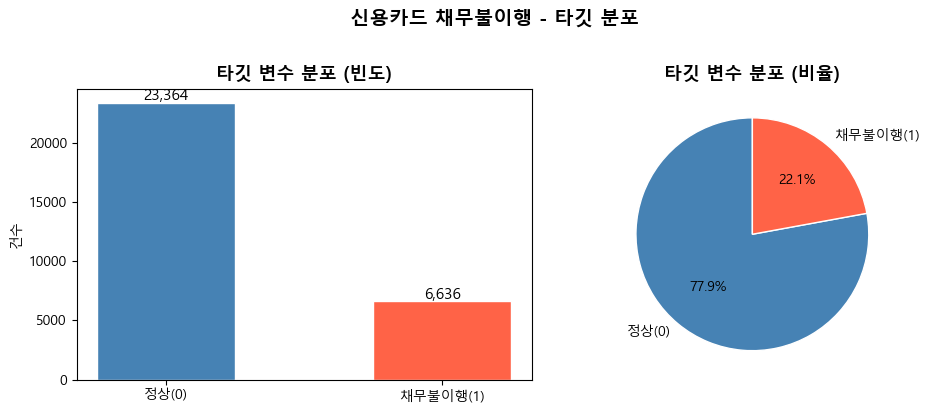

In [13]:
# ── 1-3. 타깃(default) 분포 시각화 ───────────────────────────
print("=" * 55)
print("▶ 1-3. 타깃 변수(default) 분포")
print("=" * 55)

target_counts = card_df['default'].value_counts()
target_ratio  = card_df['default'].value_counts(normalize=True) * 100

print(f"정상(0): {target_counts[0]:,}건  ({target_ratio[0]:.1f}%)")
print(f"불이행(1): {target_counts[1]:,}건  ({target_ratio[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 막대 그래프
axes[0].bar(['정상(0)', '채무불이행(1)'], target_counts,
            color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title('타깃 변수 분포 (빈도)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('건수')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# 파이 차트
axes[1].pie(target_counts, labels=['정상(0)', '채무불이행(1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('타깃 변수 분포 (비율)', fontsize=13, fontweight='bold')

plt.suptitle('신용카드 채무불이행 - 타깃 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

▶ 1-4. 범주형 피처 분포 (SEX, EDUCATION, MARRIAGE)


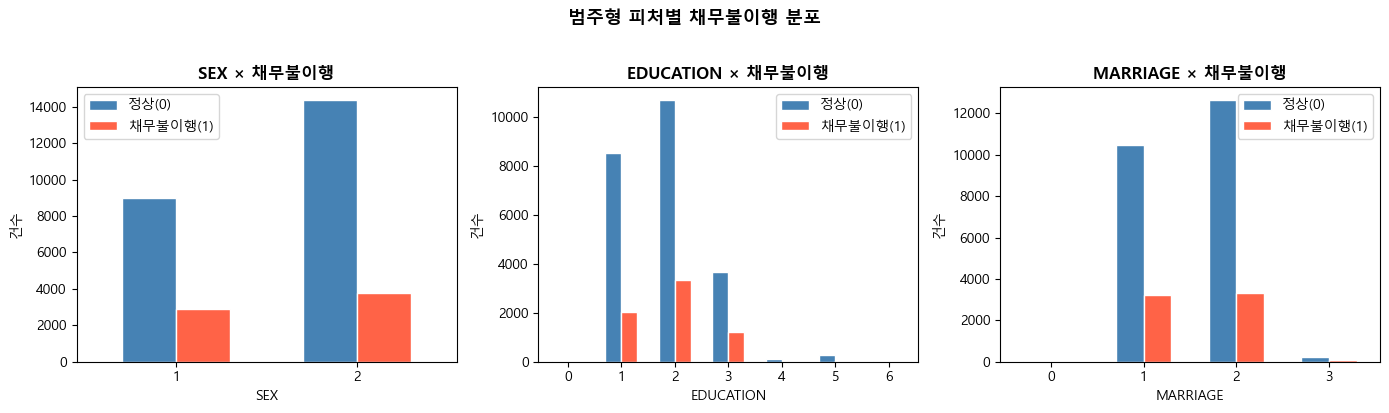

In [14]:
# ── 1-4. 범주형 피처 분포 ─────────────────────────────────────
print("=" * 55)
print("▶ 1-4. 범주형 피처 분포 (SEX, EDUCATION, MARRIAGE)")
print("=" * 55)

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
cat_labels = {
    'SEX':       {1: '남성', 2: '여성'},
    'EDUCATION': {1: '대학원', 2: '대학교', 3: '고등학교', 4: '기타', 5: '알수없음', 6: '알수없음2'},
    'MARRIAGE':  {0: '알수없음', 1: '기혼', 2: '미혼', 3: '기타'}
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, cat_cols):
    data = card_df.groupby([col, 'default']).size().unstack(fill_value=0)
    data.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
              edgecolor='white', width=0.6)
    ax.set_title(f'{col} × 채무불이행', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('건수')
    ax.legend(['정상(0)', '채무불이행(1)'])
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('범주형 피처별 채무불이행 분포', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

▶ 1-5. 수치형 피처 기초 통계
             count       mean        std       min       25%       50%  \
LIMIT_BAL  30000.0  167484.32  129747.66   10000.0  50000.00  140000.0   
SEX        30000.0       1.60       0.49       1.0      1.00       2.0   
EDUCATION  30000.0       1.85       0.79       0.0      1.00       2.0   
MARRIAGE   30000.0       1.55       0.52       0.0      1.00       2.0   
AGE        30000.0      35.49       9.22      21.0     28.00      34.0   
PAY_0      30000.0      -0.02       1.12      -2.0     -1.00       0.0   
PAY_2      30000.0      -0.13       1.20      -2.0     -1.00       0.0   
PAY_3      30000.0      -0.17       1.20      -2.0     -1.00       0.0   
PAY_4      30000.0      -0.22       1.17      -2.0     -1.00       0.0   
PAY_5      30000.0      -0.27       1.13      -2.0     -1.00       0.0   
PAY_6      30000.0      -0.29       1.15      -2.0     -1.00       0.0   
BILL_AMT1  30000.0   51223.33   73635.86 -165580.0   3558.75   22381.5   
BILL_AMT2  30000.0

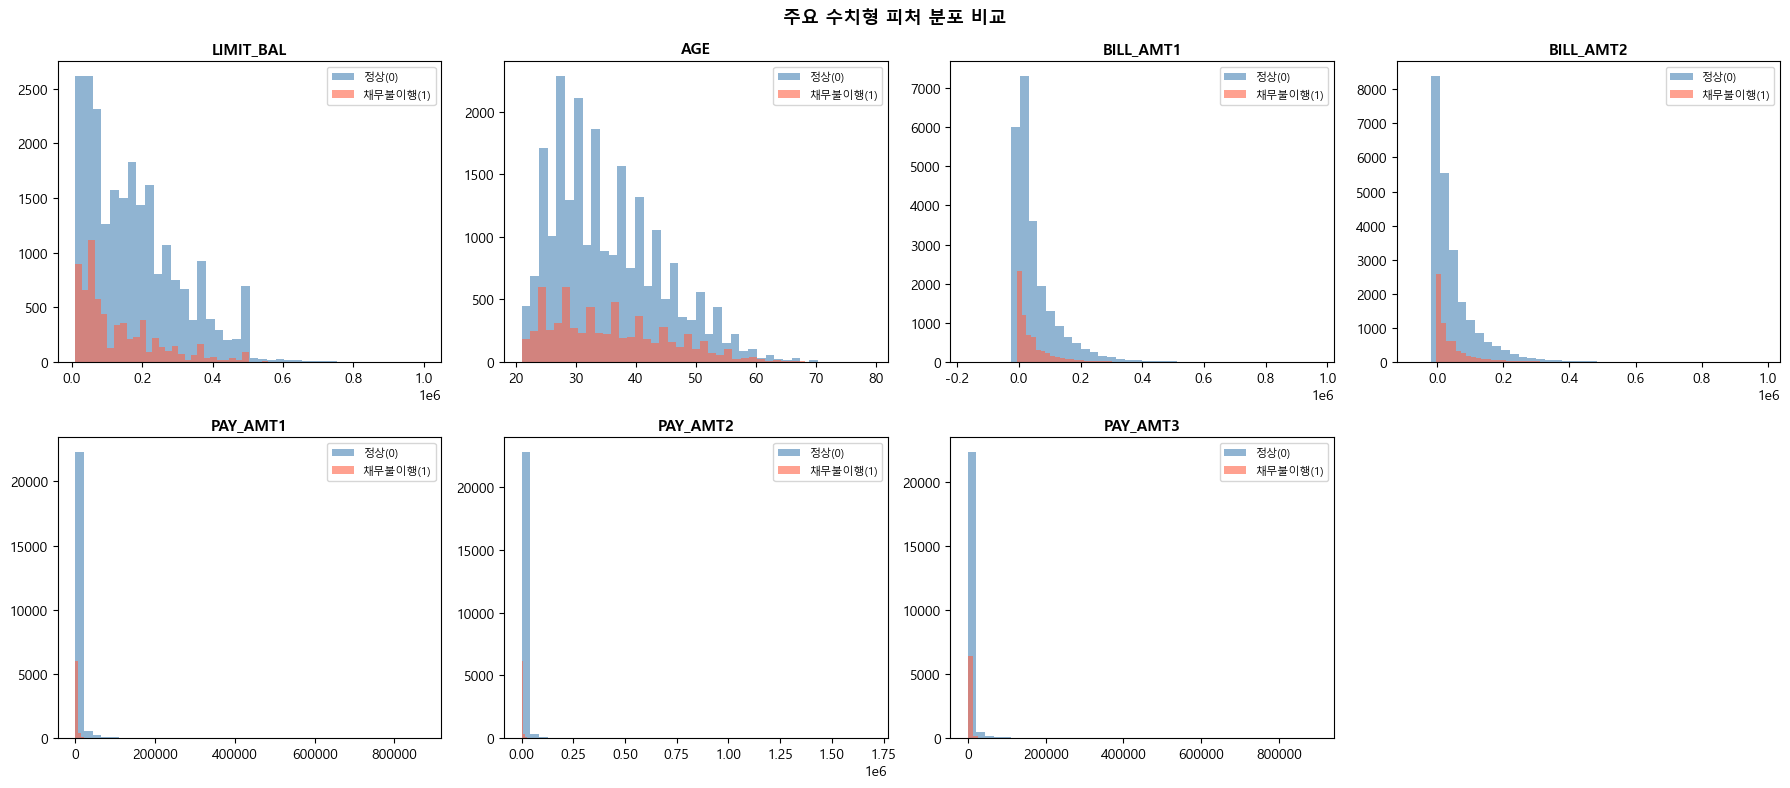

In [15]:
# ── 1-5. 수치형 피처 분포 (히스토그램) ───────────────────────
print("=" * 55)
print("▶ 1-5. 수치형 피처 기초 통계")
print("=" * 55)
print(card_df.describe().T.round(2))

num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(card_df[card_df['default'] == 0][col],
                 bins=40, alpha=0.6, color='steelblue', label='정상(0)')
    axes[i].hist(card_df[card_df['default'] == 1][col],
                 bins=40, alpha=0.6, color='tomato',    label='채무불이행(1)')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')  # 빈 칸 숨김
plt.suptitle('주요 수치형 피처 분포 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

▶ 1-6. 피처 간 상관관계 히트맵


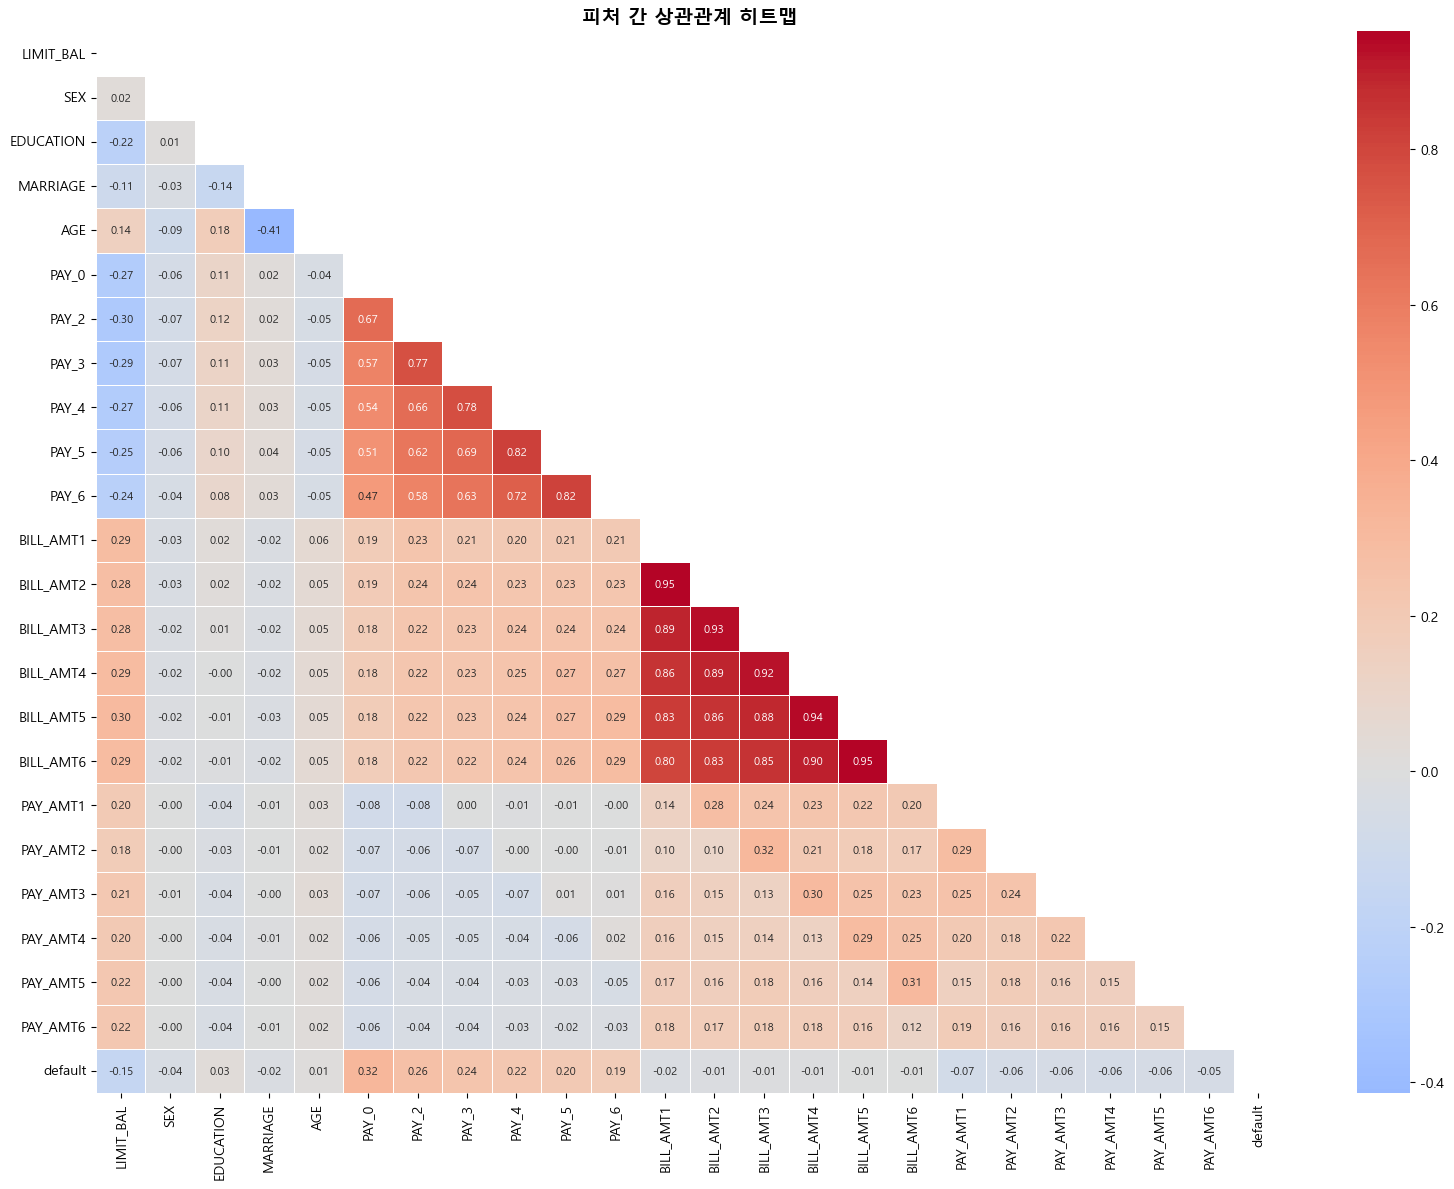


▶ default 와의 상관관계 Top 10:
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
Name: default, dtype: float64


In [16]:
# ── 1-6. 상관관계 히트맵 ─────────────────────────────────────
print("=" * 55)
print("▶ 1-6. 피처 간 상관관계 히트맵")
print("=" * 55)

corr = card_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # 상삼각 숨김
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('피처 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# default와 상관관계 높은 피처 Top 10
print("\n▶ default 와의 상관관계 Top 10:")
print(corr['default'].abs().sort_values(ascending=False)[1:11])

✅ EDA 단계 체크리스트
항목내용
1-1데이터 크기 및 컬럼 정보
1-2결측치 확인
1-3타깃(default) 분포 → 클래스 불균형 확인
1-4범주형 피처(SEX, EDUCATION, MARRIAGE) 분포
1-5수치형 피처 분포 비교
1-6상관관계 히트맵

# 2 데이터 전처리 

In [17]:
# ============================================================
# Step 2-1. 범주형 피처 인코딩
# ============================================================

print("=" * 55)
print("▶ 전처리 전 범주형 피처 고유값 확인")
print("=" * 55)

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for col in cat_cols:
    print(f"  {col}: {sorted(card_df[col].unique())}")

# ── EDUCATION: 0, 5, 6 → 4(기타)로 통합 ──────────────────────
card_df['EDUCATION'] = card_df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# ── MARRIAGE: 0 → 3(기타)으로 통합 ───────────────────────────
card_df['MARRIAGE'] = card_df['MARRIAGE'].replace({0: 3})

print("\n✅ 이상 코드 통합 완료")
print("=" * 55)
print("▶ 전처리 후 범주형 피처 고유값 확인")
print("=" * 55)
for col in cat_cols:
    print(f"  {col}: {sorted(card_df[col].unique())}")

# ── One-Hot Encoding ──────────────────────────────────────────
card_encoded = pd.get_dummies(card_df, columns=cat_cols, drop_first=False)

# bool → int 변환
bool_cols = card_encoded.select_dtypes(include='bool').columns
card_encoded[bool_cols] = card_encoded[bool_cols].astype(int)

print(f"\n✅ One-Hot Encoding 완료")
print(f"   인코딩 전 컬럼 수: {card_df.shape[1]}  →  인코딩 후: {card_encoded.shape[1]}")
print(f"   추가된 컬럼: {[c for c in card_encoded.columns if c not in card_df.columns]}")
card_encoded.head(3)

▶ 전처리 전 범주형 피처 고유값 확인
  SEX: [np.int64(1), np.int64(2)]
  EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

✅ 이상 코드 통합 완료
▶ 전처리 후 범주형 피처 고유값 확인
  SEX: [np.int64(1), np.int64(2)]
  EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]

✅ One-Hot Encoding 완료
   인코딩 전 컬럼 수: 24  →  인코딩 후: 30
   추가된 컬럼: ['SEX_1', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,default,SEX_1,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,1,0,1,0,1,0,0,1,0,0
1,120000,26,-1,2,0,0,0,2,2682,1725,...,1,0,1,0,1,0,0,0,1,0
2,90000,34,0,0,0,0,0,0,29239,14027,...,0,0,1,0,1,0,0,0,1,0


# 2.2 피처 스케일링

In [18]:
# ============================================================
# Step 2-2. 수치형 피처 스케일링 (StandardScaler)
# ============================================================
from sklearn.preprocessing import StandardScaler

# ── 스케일링 대상 컬럼 선정 (타깃 및 인코딩 컬럼 제외) ────────
scale_cols = [c for c in card_encoded.columns
              if c != 'default'
              and not any(c.startswith(cat) for cat in ['SEX_', 'EDUCATION_', 'MARRIAGE_'])]

print("=" * 55)
print("▶ 스케일링 대상 피처 목록")
print("=" * 55)
print(scale_cols)

# ── StandardScaler 적용 ───────────────────────────────────────
scaler = StandardScaler()

card_scaled = card_encoded.copy()
card_scaled[scale_cols] = scaler.fit_transform(card_encoded[scale_cols])

print(f"\n✅ StandardScaler 적용 완료 ({len(scale_cols)}개 피처)")

print("\n▶ 스케일링 전후 비교 (LIMIT_BAL, AGE)")
compare = pd.DataFrame({
    '스케일링 전 평균': card_encoded[['LIMIT_BAL', 'AGE']].mean().round(2),
    '스케일링 전 std':  card_encoded[['LIMIT_BAL', 'AGE']].std().round(2),
    '스케일링 후 평균': card_scaled[['LIMIT_BAL', 'AGE']].mean().round(4),
    '스케일링 후 std':  card_scaled[['LIMIT_BAL', 'AGE']].std().round(4),
})
print(compare.to_string())

▶ 스케일링 대상 피처 목록
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

✅ StandardScaler 적용 완료 (20개 피처)

▶ 스케일링 전후 비교 (LIMIT_BAL, AGE)
           스케일링 전 평균  스케일링 전 std  스케일링 후 평균  스케일링 후 std
LIMIT_BAL  167484.32   129747.66       -0.0         1.0
AGE            35.49        9.22       -0.0         1.0


▶ PCA 전 데이터 크기
  원본 피처 수 : 29개

  분산 90% 설명 : 13개 컴포넌트
  분산 95% 설명 : 16개 컴포넌트
  분산 99% 설명 : 20개 컴포넌트


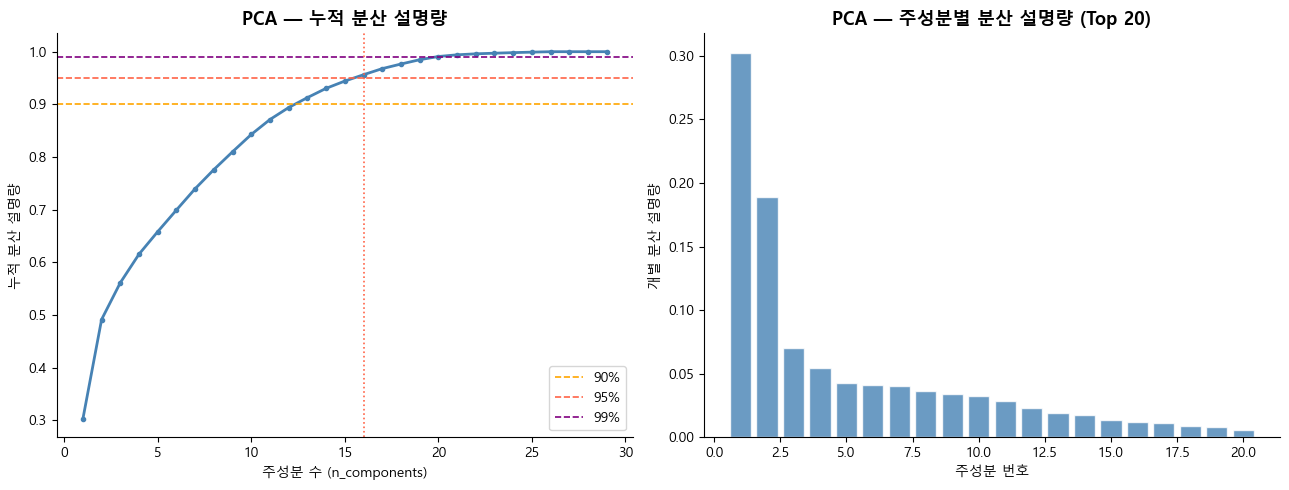

▶ PCA 적용 결과
  원본 피처 수  : 29개
  PCA 후 피처 수: 16개  (축소율 44.8%)
  누적 분산 설명량: 95.63%

✅ PCA 완료 → X shape: (30000, 16)
   y shape    : (30000,)

⚠️  주의: PCA 적용 시 Step 6 피처 중요도 해석 불가
   (PC1~PC16 는 원본 피처의 선형 조합)

✅ Step 2-2.5 완료 → 다음: Step 3 Train/Test Split


In [53]:
# ============================================================
# Step 2-2.5. PCA (주성분 분석)
#             스케일링 완료 후 / Train/Test Split 전 적용
# ============================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── PCA 대상 피처 (타깃 제외) ─────────────────────────────────
X_for_pca = card_scaled.drop(columns=['default'])
y = card_scaled['default']

print("=" * 55)
print("▶ PCA 전 데이터 크기")
print("=" * 55)
print(f"  원본 피처 수 : {X_for_pca.shape[1]}개")

# ── 1단계: 전체 분산 설명량 확인 (최적 n 탐색) ───────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_for_pca)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# 90% / 95% / 99% 기준 컴포넌트 수
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1

print(f"\n  분산 90% 설명 : {n_90}개 컴포넌트")
print(f"  분산 95% 설명 : {n_95}개 컴포넌트")
print(f"  분산 99% 설명 : {n_99}개 컴포넌트")

# ── 시각화: 누적 분산 설명량 (Elbow Plot) ────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o',
         markersize=3, color='steelblue', linewidth=2)
ax1.axhline(y=0.90, color='orange', linestyle='--', linewidth=1.2, label='90%')
ax1.axhline(y=0.95, color='tomato',  linestyle='--', linewidth=1.2, label='95%')
ax1.axhline(y=0.99, color='purple',  linestyle='--', linewidth=1.2, label='99%')
ax1.axvline(x=n_95, color='tomato', linestyle=':', linewidth=1.2)
ax1.set_xlabel('주성분 수 (n_components)')
ax1.set_ylabel('누적 분산 설명량')
ax1.set_title('PCA — 누적 분산 설명량', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.spines[['top', 'right']].set_visible(False)

# 개별 분산 설명량 (상위 20개)
ax2.bar(range(1, 21),
        pca_full.explained_variance_ratio_[:20],
        color='steelblue', edgecolor='white', alpha=0.8)
ax2.set_xlabel('주성분 번호')
ax2.set_ylabel('개별 분산 설명량')
ax2.set_title('PCA — 주성분별 분산 설명량 (Top 20)',
              fontsize=13, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── 2단계: 최적 n_components 설정 후 PCA 적용 ────────────────
# 95% 기준 권장 / 필요 시 아래 숫자를 직접 변경
N_COMPONENTS = n_95   # ← 여기서 원하는 숫자로 변경 가능

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

# DataFrame으로 변환
col_names = [f'PC{i+1}' for i in range(N_COMPONENTS)]
X = pd.DataFrame(X_pca, columns=col_names, index=X_for_pca.index)

print("=" * 55)
print("▶ PCA 적용 결과")
print("=" * 55)
print(f"  원본 피처 수  : {X_for_pca.shape[1]}개")
print(f"  PCA 후 피처 수: {X.shape[1]}개  (축소율 {(1 - X.shape[1]/X_for_pca.shape[1])*100:.1f}%)")
print(f"  누적 분산 설명량: {cumvar[N_COMPONENTS-1]*100:.2f}%")
print(f"\n✅ PCA 완료 → X shape: {X.shape}")
print(f"   y shape    : {y.shape}")
print(f"\n⚠️  주의: PCA 적용 시 Step 6 피처 중요도 해석 불가")
print(f"   (PC1~PC{N_COMPONENTS} 는 원본 피처의 선형 조합)")
print(f"\n✅ Step 2-2.5 완료 → 다음: Step 3 Train/Test Split")


In [19]:
# ============================================================
# Step 2-3. 불필요 컬럼 제거 및 최종 X / y 분리
# ============================================================

print("=" * 55)
print("▶ 최종 컬럼 목록 확인")
print("=" * 55)
print(card_scaled.columns.tolist())

# ── 타깃 분리 ─────────────────────────────────────────────────
X = card_scaled.drop(columns=['default'])
y = card_scaled['default']

print(f"\n✅ X (피처) shape : {X.shape}")
print(f"✅ y (타깃) shape : {y.shape}")
print(f"\n▶ 타깃 분포 확인")
print(y.value_counts().rename({0: '정상(0)', 1: '채무불이행(1)'}))
print(f"\n▶ 피처 목록 ({X.shape[1]}개):")
print(X.columns.tolist())

▶ 최종 컬럼 목록 확인
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default', 'SEX_1', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']

✅ X (피처) shape : (30000, 29)
✅ y (타깃) shape : (30000,)

▶ 타깃 분포 확인
default
정상(0)       23364
채무불이행(1)     6636
Name: count, dtype: int64

▶ 피처 목록 (29개):
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'SEX_1', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']


In [20]:
# ============================================================
# Step 2-4. 전처리 결과 최종 검증
# ============================================================

print("=" * 55)
print("▶ 전처리 최종 검증 리포트")
print("=" * 55)

checks = {
    '결측치 없음':       X.isnull().sum().sum() == 0,
    '타깃 분리 완료':    'default' not in X.columns,
    '수치형 스케일링':   abs(X[scale_cols].mean()).max() < 0.01,
    '범주형 인코딩':     all(c not in X.columns for c in ['SEX','EDUCATION','MARRIAGE']),
}

for check, result in checks.items():
    mark = '✅' if result else '❌'
    print(f"  {mark} {check}")

print(f"\n▶ 최종 데이터셋 크기")
print(f"   X : {X.shape[0]:,} rows × {X.shape[1]} cols")
print(f"   y : {y.shape[0]:,} rows")
print(f"\n✅ Step 2 완료 → 다음: Step 3 Train/Test Split")

▶ 전처리 최종 검증 리포트
  ✅ 결측치 없음
  ✅ 타깃 분리 완료
  ✅ 수치형 스케일링
  ✅ 범주형 인코딩

▶ 최종 데이터셋 크기
   X : 30,000 rows × 29 cols
   y : 30,000 rows

✅ Step 2 완료 → 다음: Step 3 Train/Test Split


# 3 Train/Test Split 

In [21]:
# ============================================================
# Step 3-1. Train / Test Split
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80 : 20 분할
    random_state=42,     # 재현성 고정
    stratify=y           # 클래스 비율 유지
)

print("=" * 55)
print("▶ Train / Test 분할 결과")
print("=" * 55)
print(f"  전체 데이터  : {X.shape[0]:,} rows")
print(f"  Train 세트   : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test  세트   : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

▶ Train / Test 분할 결과
  전체 데이터  : 30,000 rows
  Train 세트   : 24,000 rows (80%)
  Test  세트   : 6,000 rows  (20%)


In [22]:
# ============================================================
# Step 3-2. stratify 옵션 적용 결과 검증
# ============================================================

train_ratio = y_train.value_counts(normalize=True) * 100
test_ratio  = y_test.value_counts(normalize=True)  * 100
full_ratio  = y.value_counts(normalize=True)        * 100

ratio_df = pd.DataFrame({
    '전체 데이터': full_ratio,
    'Train 세트':  train_ratio,
    'Test  세트':  test_ratio,
}).rename(index={0: '정상(0)', 1: '채무불이행(1)'}).round(2)

print("=" * 55)
print("▶ 클래스 비율 비교 (stratify 검증)")
print("=" * 55)
print(ratio_df.to_string())
print("\n✅ 전체 / Train / Test 비율이 동일하면 stratify 정상 적용")

▶ 클래스 비율 비교 (stratify 검증)
          전체 데이터  Train 세트  Test  세트
default                             
정상(0)      77.88     77.88     77.88
채무불이행(1)   22.12     22.12     22.12

✅ 전체 / Train / Test 비율이 동일하면 stratify 정상 적용


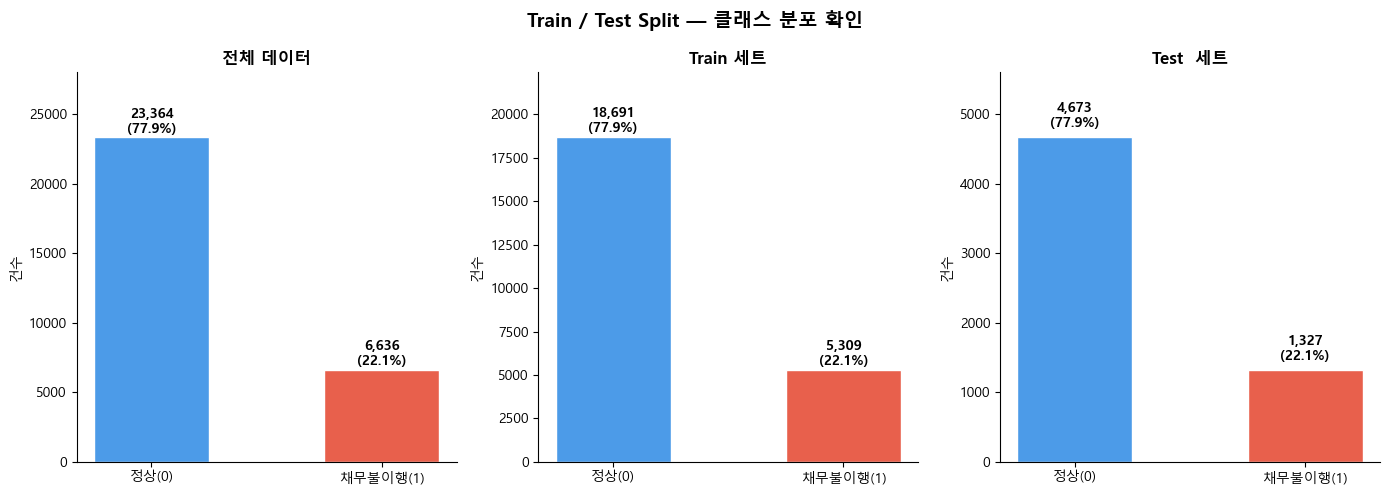

In [23]:
# ============================================================
# Step 3-3. Train / Test 클래스 분포 시각화
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Train / Test Split — 클래스 분포 확인', fontsize=14, fontweight='bold')

datasets = {
    '전체 데이터': y,
    'Train 세트':  y_train,
    'Test  세트':  y_test
}
colors = ['#4C9BE8', '#E8604C']

for ax, (title, data) in zip(axes, datasets.items()):
    counts = data.value_counts().sort_index()
    bars = ax.bar(['정상(0)', '채무불이행(1)'], counts,
                  color=colors, edgecolor='white', width=0.5)
    for bar, count in zip(bars, counts):
        pct = count / len(data) * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 100,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('건수')
    ax.set_ylim(0, counts.max() * 1.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# Step 3-4. 최종 Shape 확인 및 다음 단계 준비 완료
# ============================================================

print("=" * 55)
print("▶ Step 3 최종 결과 요약")
print("=" * 55)
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  |  불이행 비율: {y_train.mean()*100:.1f}%")
print(f"  y_test  : {y_test.shape}   |  불이행 비율: {y_test.mean()*100:.1f}%")
print()
print("✅ Step 3 완료 → 다음: Step 4 모델 학습")
print("   (Logistic Regression → Random Forest → XGBoost)")

▶ Step 3 최종 결과 요약
  X_train : (24000, 29)
  X_test  : (6000, 29)
  y_train : (24000,)  |  불이행 비율: 22.1%
  y_test  : (6000,)   |  불이행 비율: 22.1%

✅ Step 3 완료 → 다음: Step 4 모델 학습
   (Logistic Regression → Random Forest → XGBoost)


# 4 모델 학습  

In [25]:
# ============================================================
# Step 4-1. Logistic Regression (베이스라인)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("=" * 55)
print("▶ 4-1. Logistic Regression 학습")
print("=" * 55)

lr_model = LogisticRegression(
    max_iter=1000,          # 수렴을 위해 반복 횟수 충분히
    random_state=42,
    class_weight='balanced' # 클래스 불균형 자동 보정
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("✅ Logistic Regression 학습 완료")
print(f"\n▶ Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"\n▶ Classification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['정상(0)', '채무불이행(1)']))

▶ 4-1. Logistic Regression 학습
✅ Logistic Regression 학습 완료

▶ Accuracy : 0.6785

▶ Classification Report:
              precision    recall  f1-score   support

       정상(0)       0.87      0.69      0.77      4673
    채무불이행(1)       0.37      0.63      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



In [26]:
# ============================================================
# Step 4-2. Random Forest
# ============================================================
from sklearn.ensemble import RandomForestClassifier

print("=" * 55)
print("▶ 4-2. Random Forest 학습")
print("=" * 55)

rf_model = RandomForestClassifier(
    n_estimators=300,       # 트리 개수
    max_depth=10,           # 과적합 방지
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1               # 전체 CPU 사용
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("✅ Random Forest 학습 완료")
print(f"\n▶ Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"\n▶ Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['정상(0)', '채무불이행(1)']))

▶ 4-2. Random Forest 학습
✅ Random Forest 학습 완료

▶ Accuracy : 0.7860

▶ Classification Report:
              precision    recall  f1-score   support

       정상(0)       0.88      0.85      0.86      4673
    채무불이행(1)       0.51      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



In [27]:
# ============================================================
# Step 4-3. XGBoost
# ============================================================
from xgboost import XGBClassifier

# 클래스 불균형 비율 계산
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = round(neg / pos, 2)
print(f"  scale_pos_weight 설정값: {scale}  (정상 {neg:,} / 불이행 {pos:,})")

print("=" * 55)
print("▶ 4-3. XGBoost 학습")
print("=" * 55)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,  # 클래스 불균형 보정
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_pred = xgb_model.predict(X_test)

print("✅ XGBoost 학습 완료")
print(f"\n▶ Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"\n▶ Classification Report:")
print(classification_report(y_test, xgb_pred,
      target_names=['정상(0)', '채무불이행(1)']))

  scale_pos_weight 설정값: 3.52  (정상 18,691 / 불이행 5,309)
▶ 4-3. XGBoost 학습
✅ XGBoost 학습 완료

▶ Accuracy : 0.7637

▶ Classification Report:
              precision    recall  f1-score   support

       정상(0)       0.88      0.81      0.84      4673
    채무불이행(1)       0.47      0.60      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.76      0.77      6000



In [28]:
# ============================================================
# Step 4-4. 3개 모델 성능 비교표
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

models = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest':       (rf_model, rf_pred),
    'XGBoost':             (xgb_model, xgb_pred),
}

results = []
for name, (model, pred) in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    results.append({
        '모델':        name,
        'Accuracy':    round(accuracy_score(y_test, pred),  4),
        'Precision':   round(precision_score(y_test, pred), 4),
        'Recall':      round(recall_score(y_test, pred),    4),
        'F1-Score':    round(f1_score(y_test, pred),        4),
        'ROC-AUC':     round(roc_auc_score(y_test, prob),   4),
    })

result_df = pd.DataFrame(results).set_index('모델')
print("=" * 65)
print("▶ Step 4 모델 성능 비교")
print("=" * 65)
print(result_df.to_string())

# 최고 성능 모델 자동 표시
best_model = result_df['ROC-AUC'].idxmax()
print(f"\n🏆 ROC-AUC 기준 최고 성능 모델: {best_model}  "
      f"({result_df.loc[best_model, 'ROC-AUC']})")

▶ Step 4 모델 성능 비교
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
모델                                                                 
Logistic Regression    0.6785     0.3678  0.6307    0.4646   0.7104
Random Forest          0.7860     0.5145  0.5750    0.5431   0.7752
XGBoost                0.7637     0.4731  0.6021    0.5298   0.7750

🏆 ROC-AUC 기준 최고 성능 모델: Random Forest  (0.7752)


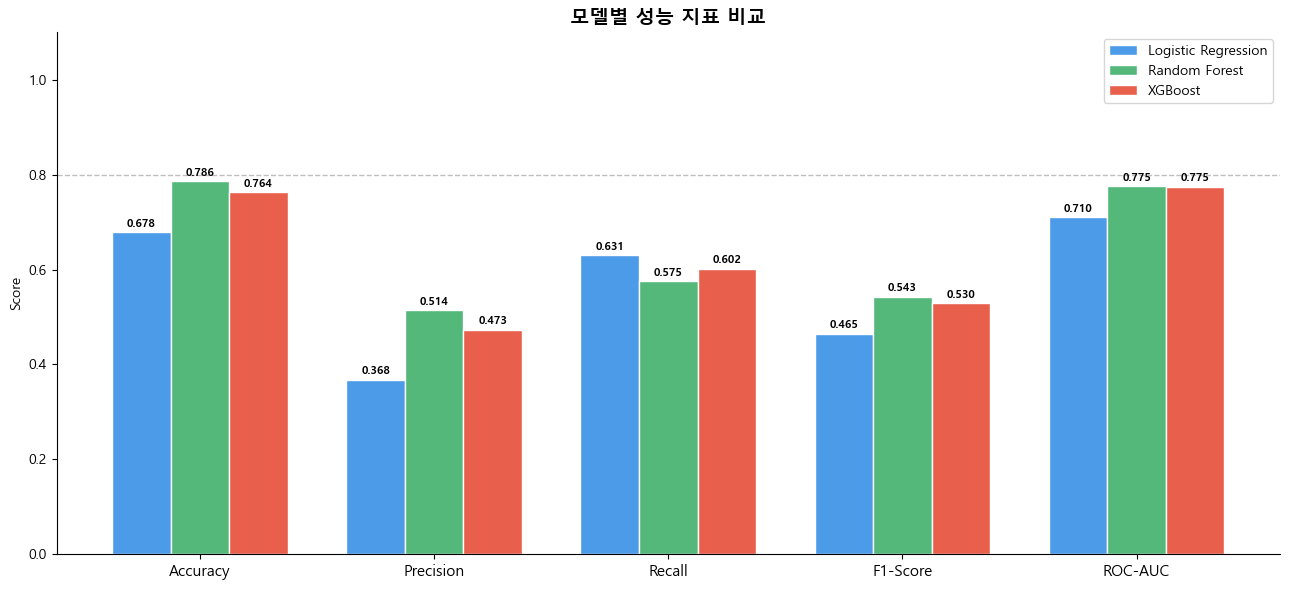

In [29]:
# ============================================================
# Step 4-5. 성능 비교 시각화
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

metrics   = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = result_df.index.tolist()
colors    = ['#4C9BE8', '#54B87A', '#E8604C']

x = range(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [result_df.loc[name, m] for m in metrics]
    bars = ax.bar([xi + i * width for xi in x], vals,
                  width=width, label=name,
                  color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('모델별 성능 지표 비교', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(y=0.8, color='gray', linestyle='--',
           linewidth=1, alpha=0.5, label='기준선 0.8')

plt.tight_layout()
plt.show()

# 5 모델 평가

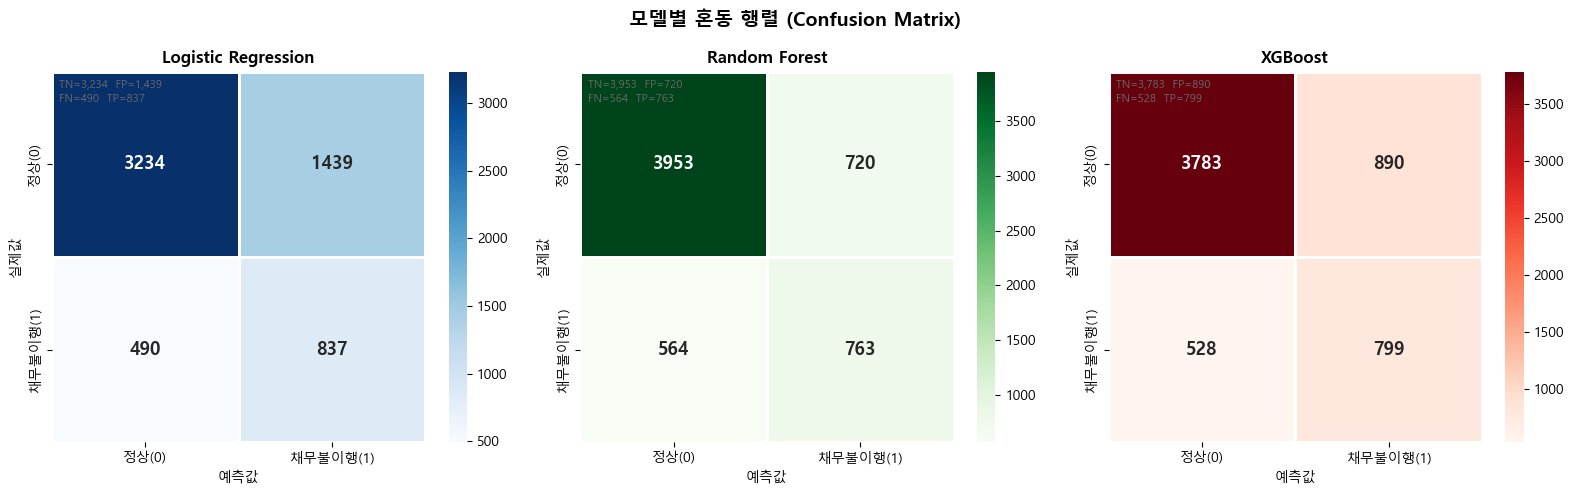

In [30]:
# ============================================================
# Step 5-1. 혼동 행렬 (Confusion Matrix)
# ============================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

models = {
    'Logistic Regression': lr_pred,
    'Random Forest':       rf_pred,
    'XGBoost':             xgb_pred,
}
colors = ['Blues', 'Greens', 'Reds']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('모델별 혼동 행렬 (Confusion Matrix)',
             fontsize=14, fontweight='bold')

for ax, (name, pred), cmap in zip(axes, models.items(), colors):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                linewidths=1, linecolor='white',
                xticklabels=['정상(0)', '채무불이행(1)'],
                yticklabels=['정상(0)', '채무불이행(1)'],
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('예측값', fontsize=10)
    ax.set_ylabel('실제값', fontsize=10)

    # TN / FP / FN / TP 라벨 표시
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.02, 0.98,
            f'TN={tn:,}  FP={fp:,}\nFN={fn:,}  TP={tp:,}',
            transform=ax.transAxes, fontsize=8,
            va='top', color='dimgray')

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# Step 5-2. 분류 리포트 상세 비교
# ============================================================
from sklearn.metrics import classification_report
import pandas as pd

print("=" * 60)
print("▶ 모델별 Classification Report 상세 비교")
print("=" * 60)

report_rows = []
for name, pred in models.items():
    report = classification_report(y_test, pred, output_dict=True,
                                   target_names=['정상(0)', '채무불이행(1)'])
    for cls in ['정상(0)', '채무불이행(1)', 'macro avg']:
        report_rows.append({
            '모델':      name,
            '클래스':    cls,
            'Precision': round(report[cls]['precision'], 4),
            'Recall':    round(report[cls]['recall'],    4),
            'F1-Score':  round(report[cls]['f1-score'],  4),
            'Support':   int(report[cls]['support']),
        })

report_df = pd.DataFrame(report_rows).set_index(['모델', '클래스'])
print(report_df.to_string())

▶ 모델별 Classification Report 상세 비교
                               Precision  Recall  F1-Score  Support
모델                  클래스                                            
Logistic Regression 정상(0)         0.8684  0.6921    0.7703     4673
                    채무불이행(1)      0.3678  0.6307    0.4646     1327
                    macro avg     0.6181  0.6614    0.6174     6000
Random Forest       정상(0)         0.8751  0.8459    0.8603     4673
                    채무불이행(1)      0.5145  0.5750    0.5431     1327
                    macro avg     0.6948  0.7105    0.7017     6000
XGBoost             정상(0)         0.8775  0.8095    0.8422     4673
                    채무불이행(1)      0.4731  0.6021    0.5298     1327
                    macro avg     0.6753  0.7058    0.6860     6000


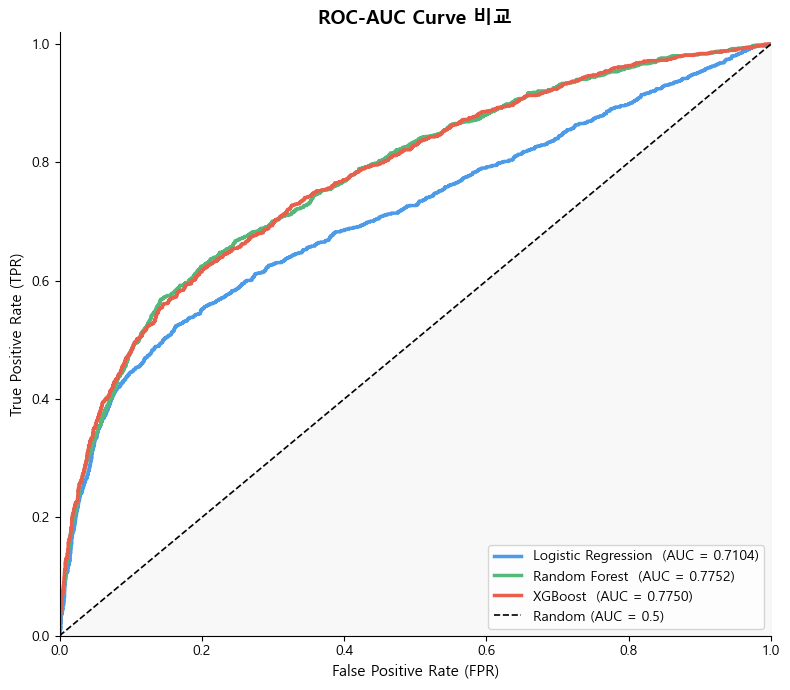

In [32]:
# ============================================================
# Step 5-3. ROC-AUC Curve
# ============================================================
from sklearn.metrics import roc_curve, roc_auc_score

model_objs = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model,
}
line_colors = ['#4C9BE8', '#54B87A', '#E8604C']

fig, ax = plt.subplots(figsize=(8, 7))

for (name, model), color in zip(model_objs.items(), line_colors):
    prob  = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc   = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc:.4f})')

# 랜덤 기준선
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random (AUC = 0.5)')

ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax.set_title('ROC-AUC Curve 비교', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

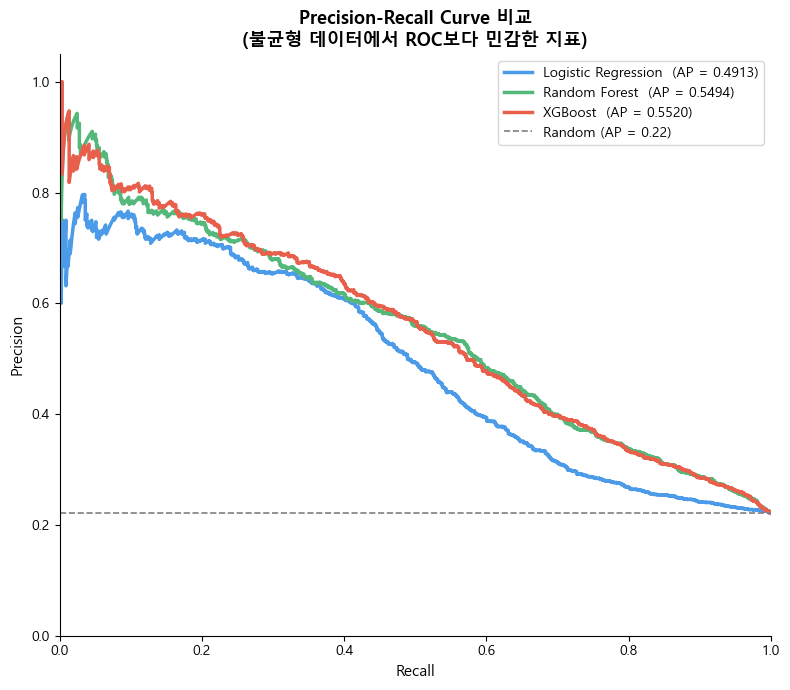

In [33]:
# ============================================================
# Step 5-4. Precision-Recall Curve
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))

for (name, model), color in zip(model_objs.items(), line_colors):
    prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, color=color, linewidth=2.5,
            label=f'{name}  (AP = {ap:.4f})')

# 기준선 (랜덤 분류기)
baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--',
           linewidth=1.2, label=f'Random (AP = {baseline:.2f})')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve 비교\n(불균형 데이터에서 ROC보다 민감한 지표)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# Step 5-5. 최종 성능 종합 요약 리포트
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             average_precision_score)

summary = []
for name, model in model_objs.items():
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    summary.append({
        '모델':        name,
        'Accuracy':    round(accuracy_score(y_test, pred),           4),
        'Precision':   round(precision_score(y_test, pred),          4),
        'Recall':      round(recall_score(y_test, pred),             4),
        'F1-Score':    round(f1_score(y_test, pred),                 4),
        'ROC-AUC':     round(roc_auc_score(y_test, prob),            4),
        'AP-Score':    round(average_precision_score(y_test, prob),  4),
    })

summary_df = pd.DataFrame(summary).set_index('모델')

print("=" * 70)
print("▶ Step 5 최종 성능 종합 요약")
print("=" * 70)
print(summary_df.to_string())

# ── 항목별 최고 모델 자동 출력 ───────────────────────────────
print("\n▶ 지표별 최고 성능 모델")
print("─" * 40)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'AP-Score']:
    best = summary_df[metric].idxmax()
    val  = summary_df.loc[best, metric]
    print(f"  {metric:<12}: 🏆 {best:<22} ({val})")

print("\n✅ Step 5 완료 → 다음: Step 6 피처 중요도 시각화")

▶ Step 5 최종 성능 종합 요약
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  AP-Score
모델                                                                           
Logistic Regression    0.6785     0.3678  0.6307    0.4646   0.7104    0.4913
Random Forest          0.7860     0.5145  0.5750    0.5431   0.7752    0.5494
XGBoost                0.7637     0.4731  0.6021    0.5298   0.7750    0.5520

▶ 지표별 최고 성능 모델
────────────────────────────────────────
  Accuracy    : 🏆 Random Forest          (0.786)
  Precision   : 🏆 Random Forest          (0.5145)
  Recall      : 🏆 Logistic Regression    (0.6307)
  F1-Score    : 🏆 Random Forest          (0.5431)
  ROC-AUC     : 🏆 Random Forest          (0.7752)
  AP-Score    : 🏆 XGBoost                (0.552)

✅ Step 5 완료 → 다음: Step 6 피처 중요도 시각화


# 6 피처 중요도 

▶ Random Forest 피처 중요도 Top 15
PAY_0        0.2303
PAY_2        0.1071
PAY_3        0.0652
PAY_4        0.0602
LIMIT_BAL    0.0511
PAY_AMT1     0.0460
PAY_5        0.0449
PAY_AMT2     0.0393
BILL_AMT1    0.0385
PAY_AMT3     0.0360
PAY_6        0.0326
BILL_AMT2    0.0308
PAY_AMT6     0.0272
BILL_AMT3    0.0254
PAY_AMT4     0.0254


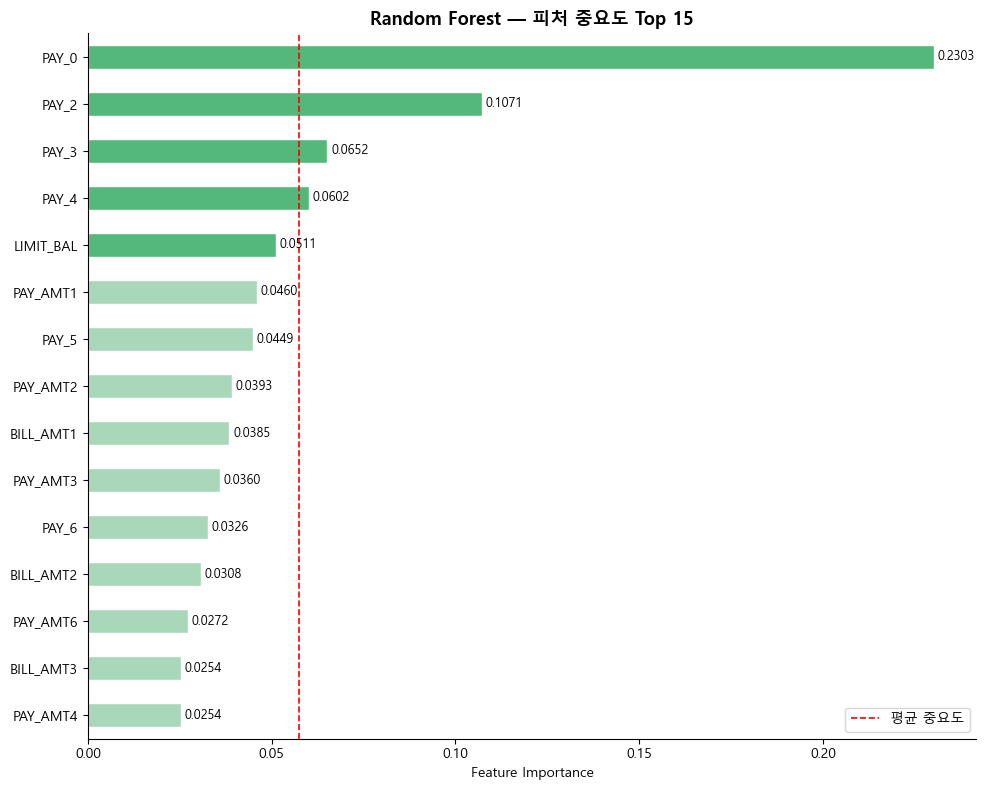

In [35]:
# ============================================================
# Step 6-1. Random Forest 피처 중요도
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 피처 중요도 추출
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("=" * 55)
print("▶ Random Forest 피처 중요도 Top 15")
print("=" * 55)
print(rf_importance.head(15).round(4).to_string())

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#54B87A' if i < 5 else '#A8D8B9'
          for i in range(len(rf_importance.head(15)))]

rf_importance.head(15).sort_values().plot(
    kind='barh', ax=ax, color=colors[::-1], edgecolor='white')

ax.set_title('Random Forest — 피처 중요도 Top 15',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance')
ax.axvline(x=rf_importance.head(15).mean(), color='red',
           linestyle='--', linewidth=1.2, label='평균 중요도')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

for i, (val, name) in enumerate(zip(
        rf_importance.head(15).sort_values(),
        rf_importance.head(15).sort_values().index)):
    ax.text(val + 0.001, i, f'{val:.4f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

scale_pos_weight : 3.52  (정상 18,691 / 불이행 5,309)
✅ XGB 베이스라인 완료
✅ XGB + scale_pos_weight 완료
   SMOTE 후: 정상 18,691  불이행 18,691
✅ XGB + SMOTE 완료

  XGBoost 3개 모델 비교 결과 (채무불이행(1) 기준)
                        Accuracy  Precision  Recall  F1-Score  ROC-AUC  AP-Score
모델                                                                              
XGB 베이스라인                 0.8167       0.65    0.36      0.47   0.7769    0.5515
XGB + scale_pos_weight    0.7637       0.47    0.60      0.53   0.7750    0.5520
XGB + SMOTE               0.7980       0.55    0.46      0.50   0.7630    0.5427
  Recall 최고  : XGB + scale_pos_weight  (0.6)
  F1 최고      : XGB + scale_pos_weight  (0.53)
  ROC-AUC 최고 : XGB 베이스라인  (0.7769)


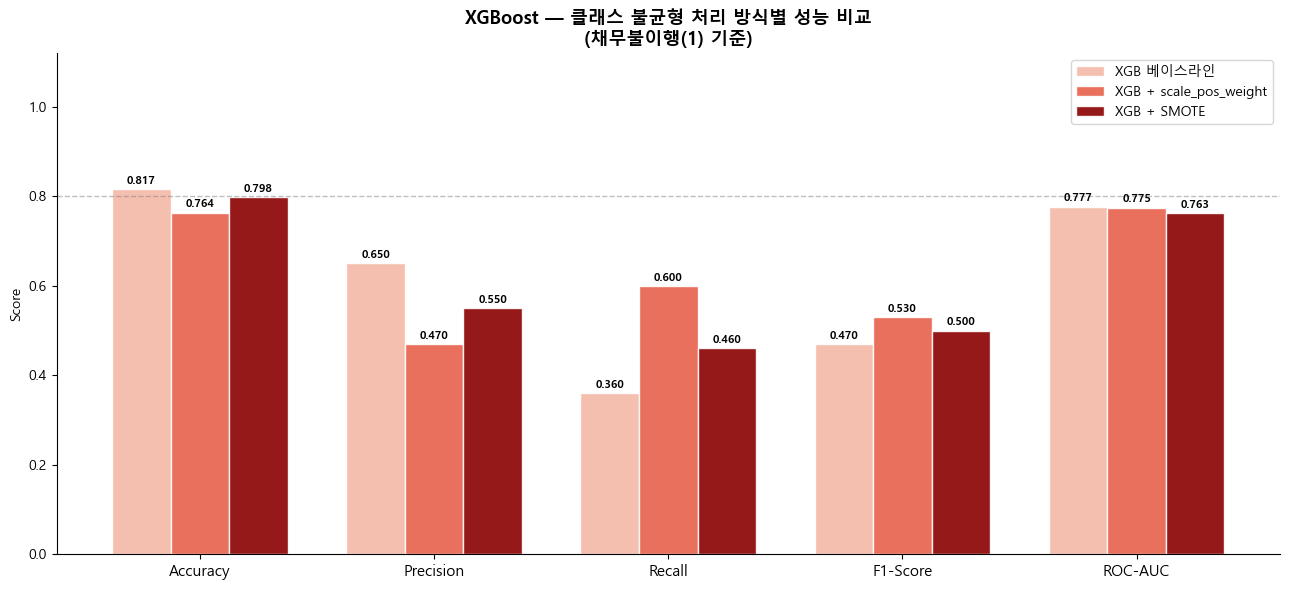

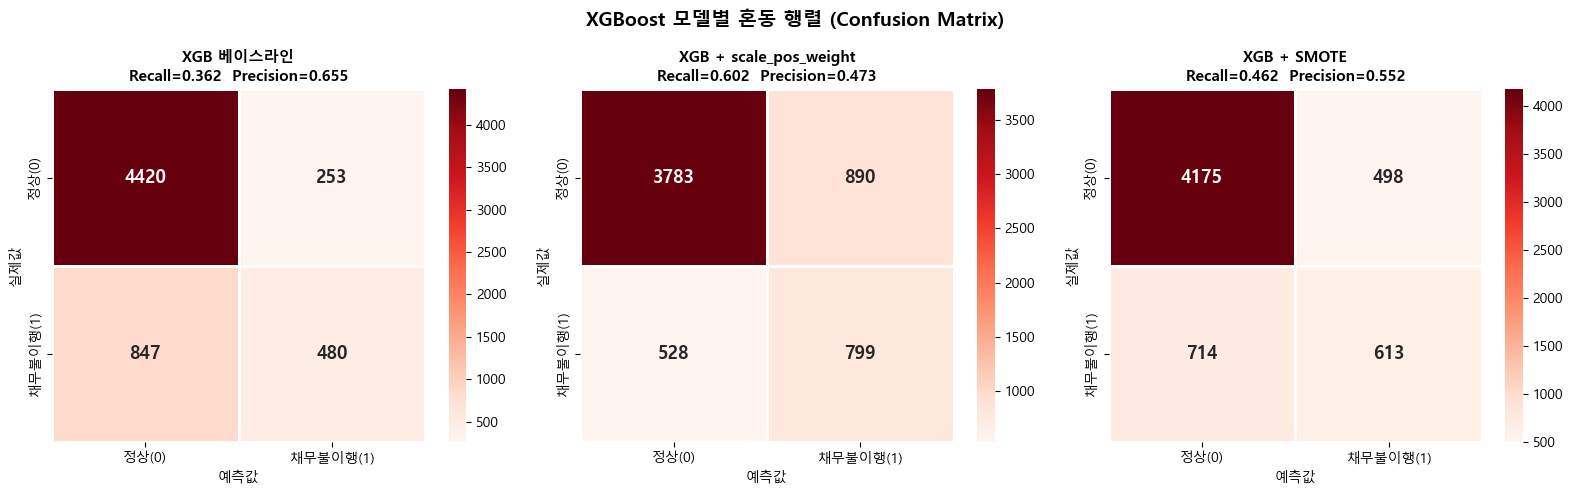

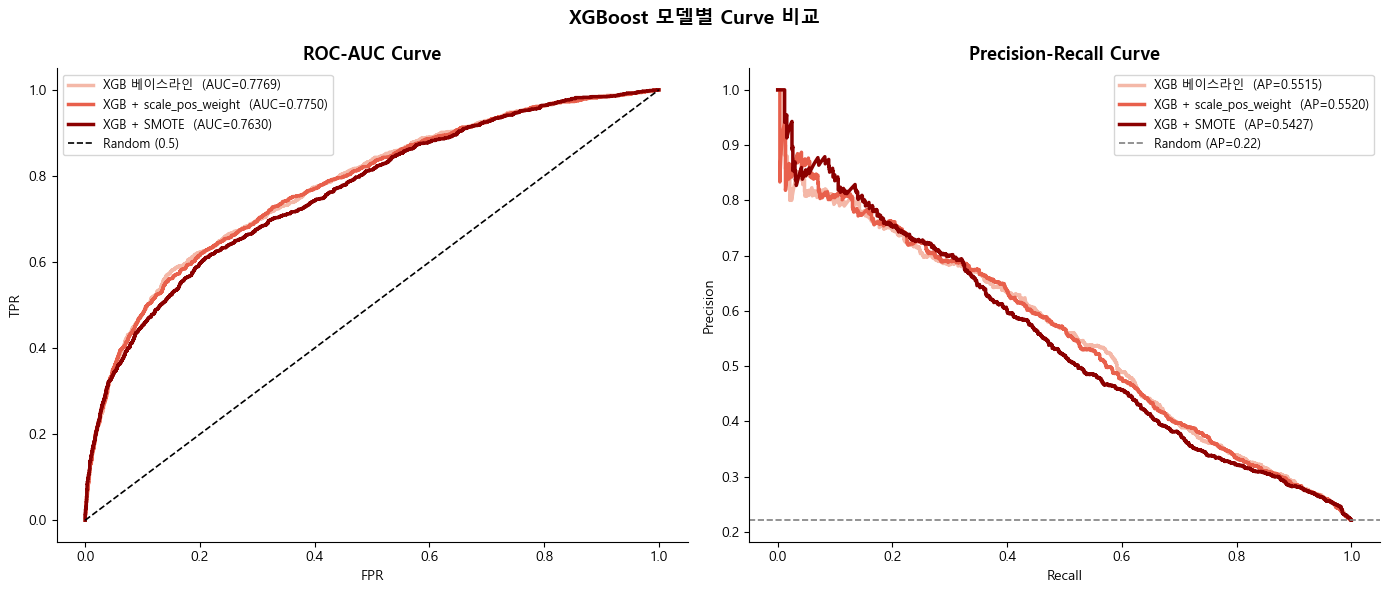

  XGBoost 3개 모델 비교 한글 해설

[Recall (재현율)]  실제 불이행 고객 중 탐지 비율
  베이스라인         : 0.36
  scale_pos_weight   : 0.60  (대비 +0.24)
  SMOTE              : 0.46  (대비 +0.10)

[Precision (정밀도)]  불이행 예측 중 실제 불이행 비율
  베이스라인         : 0.65
  scale_pos_weight   : 0.47  (대비 -0.18)
  SMOTE              : 0.55  (대비 -0.10)

[F1-Score]  Precision x Recall 조화평균
  베이스라인         : 0.47
  scale_pos_weight   : 0.53  (대비 +0.06)
  SMOTE              : 0.50  (대비 +0.03)

[ROC-AUC]  전체 판별력
  베이스라인         : 0.7769
  scale_pos_weight   : 0.7750
  SMOTE              : 0.7630

[결론]
  금융 채무불이행에서 Recall 최대화가 핵심 목표입니다.
  Recall 최고  : XGB + scale_pos_weight  (0.6)
  F1 최고      : XGB + scale_pos_weight  (0.53)
  ROC-AUC 최고 : XGB 베이스라인  (0.7769)

  ✅ Step 8 완료


In [36]:
# ============================================================
# Step 6.2. XGBoost + SMOTE 비교
#         베이스라인 XGB vs XGB + scale_pos_weight vs XGB + SMOTE
# ============================================================
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (classification_report, roc_auc_score,
                             accuracy_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 클래스 불균형 비율 ────────────────────────────────────────
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = round(neg / pos, 2)
print(f"scale_pos_weight : {scale}  (정상 {neg:,} / 불이행 {pos:,})")

# ── 1) XGB 베이스라인 ─────────────────────────────────────────
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_base.fit(X_train, y_train)
xgb_base_pred = xgb_base.predict(X_test)
xgb_base_prob = xgb_base.predict_proba(X_test)[:, 1]
print("✅ XGB 베이스라인 완료")

# ── 2) XGB + scale_pos_weight ─────────────────────────────────
xgb_spw = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_spw.fit(X_train, y_train)
xgb_spw_pred = xgb_spw.predict(X_test)
xgb_spw_prob = xgb_spw.predict_proba(X_test)[:, 1]
print("✅ XGB + scale_pos_weight 완료")

# ── 3) XGB + SMOTE ────────────────────────────────────────────
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"   SMOTE 후: 정상 {(y_train_sm==0).sum():,}  불이행 {(y_train_sm==1).sum():,}")

xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', n_jobs=-1
)
xgb_smote.fit(X_train_sm, y_train_sm)
xgb_smote_pred = xgb_smote.predict(X_test)
xgb_smote_prob = xgb_smote.predict_proba(X_test)[:, 1]
print("✅ XGB + SMOTE 완료")

# ── 성능 집계 함수 ────────────────────────────────────────────
def get_scores_xgb(pred, prob):
    report = classification_report(
        y_test, pred, output_dict=True,
        target_names=['정상(0)', '채무불이행(1)']
    )
    return {
        'Accuracy':  round(accuracy_score(y_test, pred),               4),
        'Precision': round(report['채무불이행(1)']['precision'],        2),
        'Recall':    round(report['채무불이행(1)']['recall'],            2),
        'F1-Score':  round(report['채무불이행(1)']['f1-score'],          2),
        'ROC-AUC':   round(roc_auc_score(y_test, prob),                 4),
        'AP-Score':  round(average_precision_score(y_test, prob),       4),
    }

models_xgb = {
    'XGB 베이스라인':          (xgb_base,  xgb_base_pred,  xgb_base_prob),
    'XGB + scale_pos_weight':  (xgb_spw,   xgb_spw_pred,   xgb_spw_prob),
    'XGB + SMOTE':             (xgb_smote, xgb_smote_pred, xgb_smote_prob),
}

rows = []
for name, (model, pred, prob) in models_xgb.items():
    scores = get_scores_xgb(pred, prob)
    scores['모델'] = name
    rows.append(scores)

compare_xgb = pd.DataFrame(rows).set_index('모델')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'AP-Score']
]

print()
print("=" * 65)
print("  XGBoost 3개 모델 비교 결과 (채무불이행(1) 기준)")
print("=" * 65)
print(compare_xgb.to_string())
print("=" * 65)
best_recall = compare_xgb['Recall'].idxmax()
best_f1     = compare_xgb['F1-Score'].idxmax()
best_auc    = compare_xgb['ROC-AUC'].idxmax()
print(f"  Recall 최고  : {best_recall}  ({compare_xgb.loc[best_recall, 'Recall']})")
print(f"  F1 최고      : {best_f1}  ({compare_xgb.loc[best_f1, 'F1-Score']})")
print(f"  ROC-AUC 최고 : {best_auc}  ({compare_xgb.loc[best_auc, 'ROC-AUC']})")

# ── 시각화 1: 성능 막대그래프 ─────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#F4B8A8', '#E8604C', '#8B0000']
labels  = list(compare_xgb.index)

fig, ax = plt.subplots(figsize=(13, 6))
for i, (label, color) in enumerate(zip(labels, colors)):
    vals = [compare_xgb.loc[label, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width=width,
                  color=color, edgecolor='white', label=label, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('XGBoost — 클래스 불균형 처리 방식별 성능 비교\n(채무불이행(1) 기준)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ── 시각화 2: Confusion Matrix 3개 ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('XGBoost 모델별 혼동 행렬 (Confusion Matrix)',
             fontsize=14, fontweight='bold')

for ax, (name, (model, pred, prob)) in zip(axes, models_xgb.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
                linewidths=1, linecolor='white',
                xticklabels=['정상(0)', '채무불이행(1)'],
                yticklabels=['정상(0)', '채무불이행(1)'],
                annot_kws={'size': 13, 'weight': 'bold'})
    tn, fp, fn, tp = cm.ravel()
    recall_val = round(tp / (tp + fn), 3)
    prec_val   = round(tp / (tp + fp), 3)
    ax.set_title(f'{name}\nRecall={recall_val}  Precision={prec_val}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('예측값')
    ax.set_ylabel('실제값')

plt.tight_layout()
plt.show()

# ── 시각화 3: ROC-AUC + Precision-Recall Curve ───────────────
line_colors = ['#F4B8A8', '#E8604C', '#8B0000']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for (name, (model, pred, prob)), color in zip(models_xgb.items(), line_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{name}  (AUC={auc:.4f})')
    prec_c, rec_c, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec_c, prec_c, color=color, linewidth=2.5,
             label=f'{name}  (AP={ap:.4f})')

ax1.plot([0,1], [0,1], 'k--', linewidth=1.2, label='Random (0.5)')
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC-AUC Curve', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

baseline_ap = y_test.mean()
ax2.axhline(y=baseline_ap, color='gray', linestyle='--',
            linewidth=1.2, label=f'Random (AP={baseline_ap:.2f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('XGBoost 모델별 Curve 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 최종 한글 해설 ────────────────────────────────────────────
sep = "=" * 65
print(sep)
print("  XGBoost 3개 모델 비교 한글 해설")
print(sep)

r_base  = compare_xgb.loc['XGB 베이스라인',         'Recall']
r_spw   = compare_xgb.loc['XGB + scale_pos_weight',  'Recall']
r_smote = compare_xgb.loc['XGB + SMOTE',             'Recall']
p_base  = compare_xgb.loc['XGB 베이스라인',         'Precision']
p_spw   = compare_xgb.loc['XGB + scale_pos_weight',  'Precision']
p_smote = compare_xgb.loc['XGB + SMOTE',             'Precision']
f_base  = compare_xgb.loc['XGB 베이스라인',         'F1-Score']
f_spw   = compare_xgb.loc['XGB + scale_pos_weight',  'F1-Score']
f_smote = compare_xgb.loc['XGB + SMOTE',             'F1-Score']
a_base  = compare_xgb.loc['XGB 베이스라인',         'ROC-AUC']
a_spw   = compare_xgb.loc['XGB + scale_pos_weight',  'ROC-AUC']
a_smote = compare_xgb.loc['XGB + SMOTE',             'ROC-AUC']

print("\n[Recall (재현율)]  실제 불이행 고객 중 탐지 비율")
print(f"  베이스라인         : {r_base:.2f}")
print(f"  scale_pos_weight   : {r_spw:.2f}  (대비 {r_spw - r_base:+.2f})")
print(f"  SMOTE              : {r_smote:.2f}  (대비 {r_smote - r_base:+.2f})")

print("\n[Precision (정밀도)]  불이행 예측 중 실제 불이행 비율")
print(f"  베이스라인         : {p_base:.2f}")
print(f"  scale_pos_weight   : {p_spw:.2f}  (대비 {p_spw - p_base:+.2f})")
print(f"  SMOTE              : {p_smote:.2f}  (대비 {p_smote - p_base:+.2f})")

print("\n[F1-Score]  Precision x Recall 조화평균")
print(f"  베이스라인         : {f_base:.2f}")
print(f"  scale_pos_weight   : {f_spw:.2f}  (대비 {f_spw - f_base:+.2f})")
print(f"  SMOTE              : {f_smote:.2f}  (대비 {f_smote - f_base:+.2f})")

print("\n[ROC-AUC]  전체 판별력")
print(f"  베이스라인         : {a_base:.4f}")
print(f"  scale_pos_weight   : {a_spw:.4f}")
print(f"  SMOTE              : {a_smote:.4f}")

print("\n[결론]")
print("  금융 채무불이행에서 Recall 최대화가 핵심 목표입니다.")
print(f"  Recall 최고  : {best_recall}  ({compare_xgb.loc[best_recall, 'Recall']})")
print(f"  F1 최고      : {best_f1}  ({compare_xgb.loc[best_f1, 'F1-Score']})")
print(f"  ROC-AUC 최고 : {best_auc}  ({compare_xgb.loc[best_auc, 'ROC-AUC']})")

print()
print(sep)
print("  ✅ Step 8 완료")
print(sep)


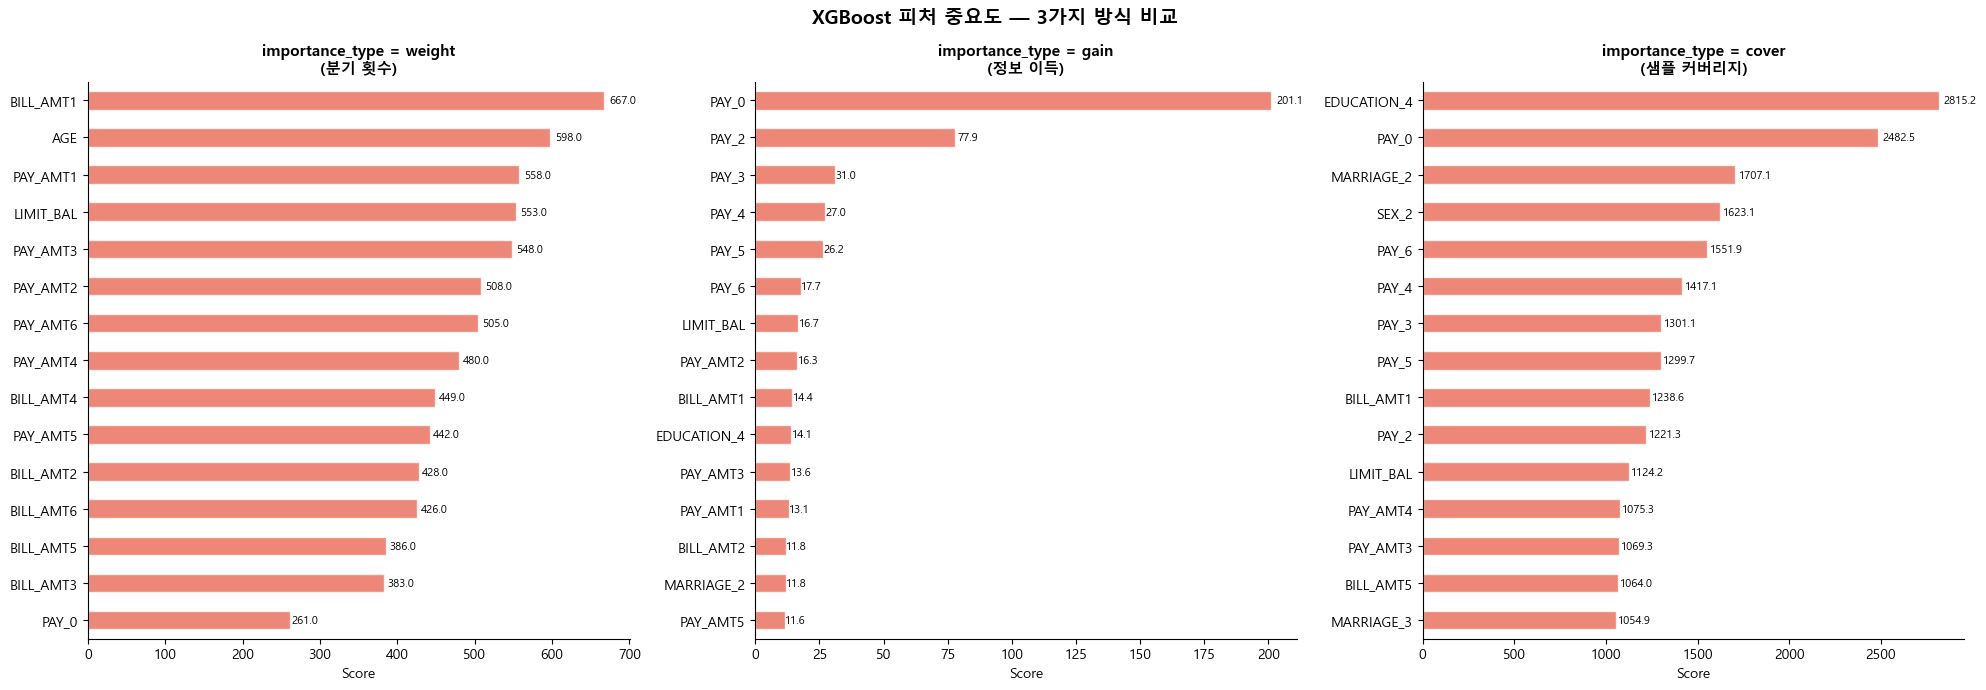

▶ XGBoost 피처 중요도 Top 15 (gain 기준)
PAY_0          201.11
PAY_2           77.90
PAY_3           31.05
PAY_4           27.03
PAY_5           26.24
PAY_6           17.73
LIMIT_BAL       16.66
PAY_AMT2        16.33
BILL_AMT1       14.37
EDUCATION_4     14.12
PAY_AMT3        13.55
PAY_AMT1        13.15
BILL_AMT2       11.82
MARRIAGE_2      11.79
PAY_AMT5        11.59


In [37]:
# ============================================================
# Step 6-3. XGBoost 피처 중요도 (3가지 방식 비교)
# ============================================================

importance_types = {
    'weight\n(분기 횟수)':  'weight',
    'gain\n(정보 이득)':    'gain',
    'cover\n(샘플 커버리지)': 'cover',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('XGBoost 피처 중요도 — 3가지 방식 비교',
             fontsize=14, fontweight='bold')

for ax, (title, itype) in zip(axes, importance_types.items()):
    xgb_imp = pd.Series(
        xgb_model.get_booster().get_score(importance_type=itype)
    ).sort_values(ascending=False).head(15)

    xgb_imp.sort_values().plot(
        kind='barh', ax=ax,
        color='#E8604C', alpha=0.75, edgecolor='white')

    ax.set_title(f'importance_type = {title}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Score')
    ax.spines[['top', 'right']].set_visible(False)

    for i, (val, name) in enumerate(zip(
            xgb_imp.sort_values(),
            xgb_imp.sort_values().index)):
        ax.text(val * 1.01, i, f'{val:.1f}',
                va='center', fontsize=8)

plt.tight_layout()
plt.show()

# gain 기준 Top 15 수치 출력
xgb_gain = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)

print("=" * 55)
print("▶ XGBoost 피처 중요도 Top 15 (gain 기준)")
print("=" * 55)
print(xgb_gain.head(15).round(2).to_string())

▶ Logistic Regression 계수 Top 15
EDUCATION_4   -0.8095
PAY_0          0.5895
BILL_AMT1     -0.2888
EDUCATION_1    0.2820
EDUCATION_2    0.1945
PAY_AMT1      -0.1912
PAY_AMT2      -0.1811
SEX_2         -0.1653
MARRIAGE_2    -0.1524
LIMIT_BAL     -0.1297
EDUCATION_3    0.1262
PAY_2          0.0993
BILL_AMT2      0.0899
PAY_3          0.0888
MARRIAGE_3    -0.0757


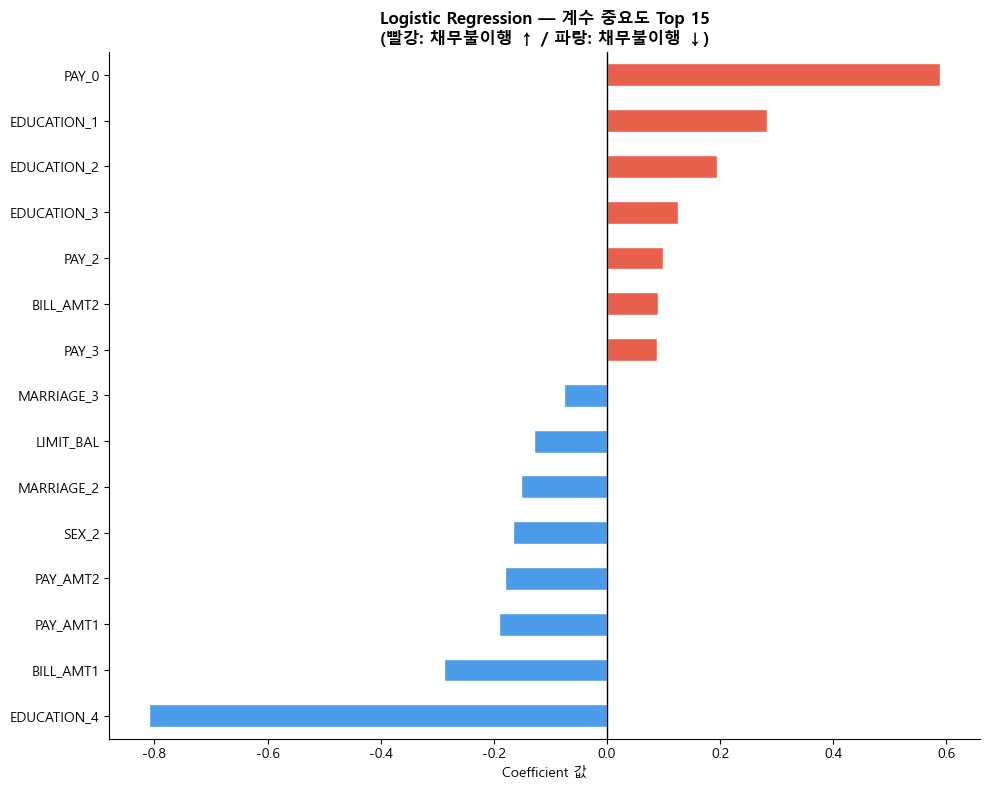

In [38]:
# ============================================================
# Step 6-4. Logistic Regression 계수(Coefficient) 중요도
# ============================================================

lr_coef = pd.Series(
    lr_model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

print("=" * 55)
print("▶ Logistic Regression 계수 Top 15")
print("=" * 55)
print(lr_coef.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#E8604C' if v > 0 else '#4C9BE8'
          for v in lr_coef.head(15).sort_values()]

lr_coef.head(15).sort_values().plot(
    kind='barh', ax=ax, color=colors, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Logistic Regression — 계수 중요도 Top 15\n'
             '(빨강: 채무불이행 ↑ / 파랑: 채무불이행 ↓)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient 값')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

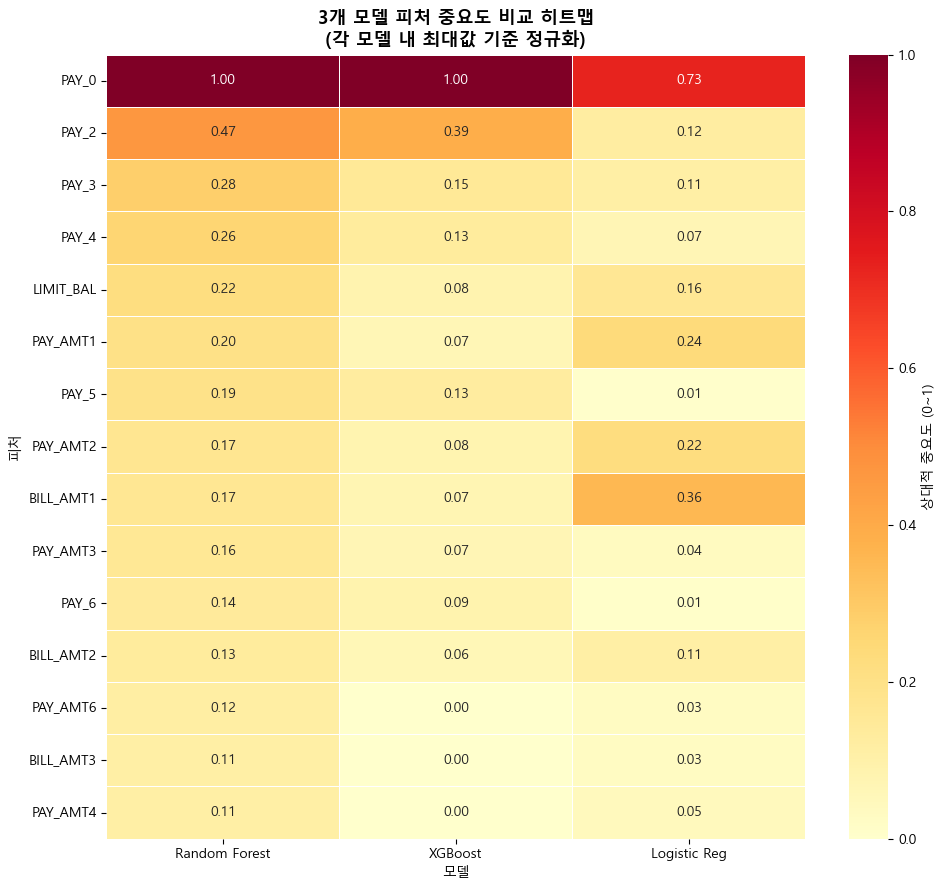

In [39]:
# ============================================================
# Step 6-5. 3개 모델 공통 Top 피처 비교 히트맵
# ============================================================

# 각 모델 Top 15 피처 추출 (정규화)
rf_top = (rf_importance.head(15) /
          rf_importance.head(15).sum()).round(4)

xgb_top_raw = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False).head(15)
xgb_top = (xgb_top_raw / xgb_top_raw.sum()).round(4)

lr_top = (lr_coef.abs().head(15) /
          lr_coef.abs().head(15).sum()).round(4)

# 공통 피처 합집합
all_features = list(set(rf_top.index) |
                    set(xgb_top.index) |
                    set(lr_top.index))

compare_df = pd.DataFrame({
    'Random Forest': rf_importance.reindex(all_features).fillna(0),
    'XGBoost':       xgb_top_raw.reindex(all_features).fillna(0),
    'Logistic Reg':  lr_coef.abs().reindex(all_features).fillna(0),
})

# 각 컬럼 정규화 (0~1)
compare_df = compare_df.apply(lambda x: x / x.max())
compare_df = compare_df.sort_values('Random Forest', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(compare_df, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': '상대적 중요도 (0~1)'})
ax.set_title('3개 모델 피처 중요도 비교 히트맵\n(각 모델 내 최대값 기준 정규화)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('모델')
ax.set_ylabel('피처')
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# Step 6-6. 핵심 피처 종합 해석 리포트
# ============================================================

# 모델별 Top 10 피처 집계
rf_top10  = set(rf_importance.head(10).index)
xgb_top10 = set(xgb_top_raw.head(10).index)
lr_top10  = set(lr_coef.abs().head(10).index)

common_all   = rf_top10 & xgb_top10 & lr_top10   # 3개 모델 공통
common_two   = ((rf_top10 & xgb_top10) |
                (rf_top10 & lr_top10)  |
                (xgb_top10 & lr_top10)) - common_all

sep = "=" * 60
print(sep)
print("  🔍 Step 6 핵심 피처 종합 해석 리포트")
print(sep)

print("\n【 3개 모델 공통 Top 10 피처 】 → 가장 신뢰도 높은 예측 변수")
for feat in sorted(common_all):
    rf_rank  = list(rf_importance.index).index(feat) + 1 if feat in rf_importance.index else '-'
    xgb_rank = list(xgb_top_raw.index).index(feat)  + 1 if feat in xgb_top_raw.index  else '-'
    lr_rank  = list(lr_coef.abs().sort_values(ascending=False).index).index(feat) + 1 \
               if feat in lr_coef.index else '-'
    print(f"  ✅ {feat:<15}  RF순위: {rf_rank:>2}  XGB순위: {xgb_rank:>2}  LR순위: {lr_rank:>2}")

print("\n【 2개 모델 공통 피처 】 → 보조 예측 변수")
for feat in sorted(common_two):
    print(f"  ▶ {feat}")

print("\n【 피처 해석 가이드 】")
guide = {
    'PAY_0':      '최근 1개월 연체 상태 → 채무불이행 예측력 가장 높음',
    'PAY_2':      '2개월 전 연체 상태 → PAY_0 다음으로 중요',
    'PAY_3':      '3개월 전 연체 상태 → 연속 연체 패턴 반영',
    'LIMIT_BAL':  '신용한도 → 낮을수록 채무불이행 위험 ↑',
    'PAY_AMT1':   '최근 납부금액 → 적을수록 위험 ↑',
    'BILL_AMT1':  '최근 청구금액 → 높을수록 상환 부담 ↑',
    'AGE':        '나이 → 연령대별 채무 패턴 차이',
}
for feat, desc in guide.items():
    if feat in X_train.columns:
        print(f"  - {feat:<12}: {desc}")

print(f"\n{sep}")
print("  ✅ Step 6 완료 → 다음: Step 7 하이퍼파라미터 튜닝 (선택)")
print(sep)

  🔍 Step 6 핵심 피처 종합 해석 리포트

【 3개 모델 공통 Top 10 피처 】 → 가장 신뢰도 높은 예측 변수
  ✅ BILL_AMT1        RF순위:  9  XGB순위:  9  LR순위:  3
  ✅ LIMIT_BAL        RF순위:  5  XGB순위:  7  LR순위: 10
  ✅ PAY_0            RF순위:  1  XGB순위:  1  LR순위:  2
  ✅ PAY_AMT2         RF순위:  8  XGB순위:  8  LR순위:  7

【 2개 모델 공통 피처 】 → 보조 예측 변수
  ▶ EDUCATION_4
  ▶ PAY_2
  ▶ PAY_3
  ▶ PAY_4
  ▶ PAY_5
  ▶ PAY_AMT1

【 피처 해석 가이드 】
  - PAY_0       : 최근 1개월 연체 상태 → 채무불이행 예측력 가장 높음
  - PAY_2       : 2개월 전 연체 상태 → PAY_0 다음으로 중요
  - PAY_3       : 3개월 전 연체 상태 → 연속 연체 패턴 반영
  - LIMIT_BAL   : 신용한도 → 낮을수록 채무불이행 위험 ↑
  - PAY_AMT1    : 최근 납부금액 → 적을수록 위험 ↑
  - BILL_AMT1   : 최근 청구금액 → 높을수록 상환 부담 ↑
  - AGE         : 나이 → 연령대별 채무 패턴 차이

  ✅ Step 6 완료 → 다음: Step 7 하이퍼파라미터 튜닝 (선택)


# 7 하이퍼 파라미터 튜닝 

In [41]:
# ============================================================
# Step 7-1. Random Forest 하이퍼파라미터 튜닝
#           RandomizedSearchCV (시간 효율적)
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 8, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4, 5],
    'max_features':      ['sqrt', 'log2', 0.5],
}

print("=" * 55)
print("▶ 7-1. Random Forest — RandomizedSearchCV 시작")
print("=" * 55)
print(f"  탐색 조합 수 : 20회  ×  CV 3-Fold")
print(f"  평가 지표   : ROC-AUC")
print()

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=20,              # 랜덤 탐색 횟수
    cv=3,                   # 3-Fold CV
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_random.fit(X_train, y_train)

print(f"\n✅ 탐색 완료")
print(f"   최적 파라미터 : {rf_random.best_params_}")
print(f"   최적 ROC-AUC  : {rf_random.best_score_:.4f}")

▶ 7-1. Random Forest — RandomizedSearchCV 시작
  탐색 조합 수 : 20회  ×  CV 3-Fold
  평가 지표   : ROC-AUC

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 탐색 완료
   최적 파라미터 : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 8}
   최적 ROC-AUC  : 0.7787


In [42]:
# ============================================================
# Step 7-2. XGBoost 하이퍼파라미터 튜닝
#           RandomizedSearchCV
# ============================================================
from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = round(neg / pos, 2)

param_dist_xgb = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6, 8],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.7, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.2, 0.5],
}

print("=" * 55)
print("▶ 7-2. XGBoost — RandomizedSearchCV 시작")
print("=" * 55)
print(f"  탐색 조합 수 : 20회  ×  CV 3-Fold")
print(f"  평가 지표   : ROC-AUC")
print()

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ),
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_random.fit(X_train, y_train)

print(f"\n✅ 탐색 완료")
print(f"   최적 파라미터 : {xgb_random.best_params_}")
print(f"   최적 ROC-AUC  : {xgb_random.best_score_:.4f}")

▶ 7-2. XGBoost — RandomizedSearchCV 시작
  탐색 조합 수 : 20회  ×  CV 3-Fold
  평가 지표   : ROC-AUC

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 탐색 완료
   최적 파라미터 : {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
   최적 ROC-AUC  : 0.7812


In [43]:
# ============================================================
# Step 7-3. 최적 파라미터로 최종 모델 재학습
# ============================================================

print("=" * 55)
print("▶ 7-3. 최적 파라미터 최종 모델 재학습")
print("=" * 55)

# ── Random Forest 최종 모델 ───────────────────────────────────
rf_best = RandomForestClassifier(
    **rf_random.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)
rf_best_pred = rf_best.predict(X_test)
print("✅ Random Forest 최종 모델 학습 완료")

# ── XGBoost 최종 모델 ─────────────────────────────────────────
xgb_best = XGBClassifier(
    **xgb_random.best_params_,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_best.fit(X_train, y_train)
xgb_best_pred = xgb_best.predict(X_test)
print("✅ XGBoost   최종 모델 학습 완료")

▶ 7-3. 최적 파라미터 최종 모델 재학습
✅ Random Forest 최종 모델 학습 완료
✅ XGBoost   최종 모델 학습 완료


In [44]:
# ============================================================
# Step 7-4. 튜닝 전후 성능 비교
# ============================================================
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

def get_scores(model, pred):
    prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy':  round(accuracy_score(y_test, pred),  4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred),    4),
        'F1-Score':  round(f1_score(y_test, pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, prob),   4),
    }

compare = pd.DataFrame({
    'RF (튜닝 전)':   get_scores(rf_model,    rf_pred),
    'RF (튜닝 후)':   get_scores(rf_best,     rf_best_pred),
    'XGB (튜닝 전)':  get_scores(xgb_model,   xgb_pred),
    'XGB (튜닝 후)':  get_scores(xgb_best,    xgb_best_pred),
})

print("=" * 65)
print("▶ 튜닝 전후 성능 비교")
print("=" * 65)
print(compare.to_string())

# 개선량 출력
print("\n▶ ROC-AUC 개선량")
rf_improve  = compare.loc['ROC-AUC', 'RF (튜닝 후)']  - compare.loc['ROC-AUC', 'RF (튜닝 전)']
xgb_improve = compare.loc['ROC-AUC', 'XGB (튜닝 후)'] - compare.loc['ROC-AUC', 'XGB (튜닝 전)']
print(f"  Random Forest : {rf_improve:+.4f}")
print(f"  XGBoost       : {xgb_improve:+.4f}")

▶ 튜닝 전후 성능 비교
           RF (튜닝 전)  RF (튜닝 후)  XGB (튜닝 전)  XGB (튜닝 후)
Accuracy      0.7860     0.7828      0.7637      0.7763
Precision     0.5145     0.5079      0.4731      0.4953
Recall        0.5750     0.5840      0.6021      0.5998
F1-Score      0.5431     0.5433      0.5298      0.5426
ROC-AUC       0.7752     0.7733      0.7750      0.7754

▶ ROC-AUC 개선량
  Random Forest : -0.0019
  XGBoost       : +0.0004


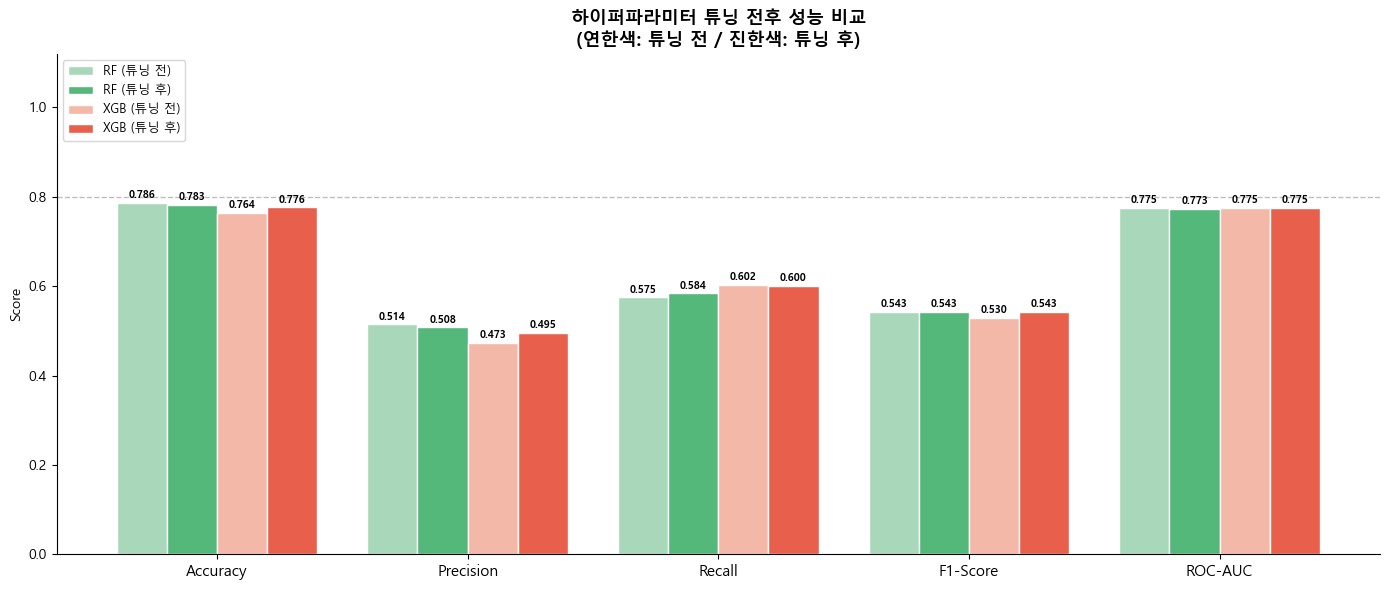

In [45]:
# ============================================================
# Step 7-5. 튜닝 전후 성능 시각화
# ============================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

colors = ['#A8D8B9', '#54B87A', '#F4B8A8', '#E8604C']
labels = ['RF (튜닝 전)', 'RF (튜닝 후)', 'XGB (튜닝 전)', 'XGB (튜닝 후)']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (col, color, label) in enumerate(zip(compare.columns, colors, labels)):
    vals = [compare.loc[m, col] for m in metrics]
    bars = ax.bar(x + i * width, vals, width=width,
                  color=color, edgecolor='white', label=label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('하이퍼파라미터 튜닝 전후 성능 비교\n(연한색: 튜닝 전 / 진한색: 튜닝 후)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.axhline(y=0.8, color='gray', linestyle='--',
           linewidth=1, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# Step 7-6. 전체 모델링 프로세스 최종 종합 리포트
# ============================================================
from sklearn.metrics import roc_auc_score

all_models = {
    'Logistic Regression': (lr_model,   lr_pred),
    'Random Forest':       (rf_model,   rf_pred),
    'XGBoost':             (xgb_model,  xgb_pred),
    'RF (튜닝 후)':        (rf_best,    rf_best_pred),
    'XGB (튜닝 후)':       (xgb_best,   xgb_best_pred),
}

final_rows = []
for name, (model, pred) in all_models.items():
    prob = model.predict_proba(X_test)[:, 1]
    final_rows.append({
        '모델':      name,
        'Accuracy':  round(accuracy_score(y_test, pred),  4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred),    4),
        'F1-Score':  round(f1_score(y_test, pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, prob),   4),
    })

final_df = pd.DataFrame(final_rows).set_index('모델')

sep = "=" * 65
print(sep)
print("  🏁 전체 모델링 프로세스 최종 종합 리포트")
print(sep)
print(final_df.to_string())

# 최종 최고 모델
best_name = final_df['ROC-AUC'].idxmax()
best_auc  = final_df.loc[best_name, 'ROC-AUC']
best_f1   = final_df.loc[best_name, 'F1-Score']

print(f"\n{'─'*65}")
print(f"  🏆 최종 선택 모델  : {best_name}")
print(f"     ROC-AUC         : {best_auc}")
print(f"     F1-Score        : {best_f1}")
print(f"{'─'*65}")
print(f"\n  📋 단계별 완료 현황")
steps = [
    ("Step 1", "EDA",                    "✅ 완료"),
    ("Step 2", "데이터 전처리",           "✅ 완료"),
    ("Step 3", "Train/Test Split",        "✅ 완료"),
    ("Step 4", "모델 학습",               "✅ 완료"),
    ("Step 5", "모델 평가",               "✅ 완료"),
    ("Step 6", "피처 중요도",             "✅ 완료"),
    ("Step 7", "하이퍼파라미터 튜닝",     "✅ 완료"),
]
for step, name, status in steps:
    print(f"  {status}  {step} — {name}")

print(f"\n{sep}")
print("  🎉 신용카드 채무불이행 예측 모델링 프로세스 완료!")
print(sep)

  🏁 전체 모델링 프로세스 최종 종합 리포트
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
모델                                                                 
Logistic Regression    0.6785     0.3678  0.6307    0.4646   0.7104
Random Forest          0.7860     0.5145  0.5750    0.5431   0.7752
XGBoost                0.7637     0.4731  0.6021    0.5298   0.7750
RF (튜닝 후)              0.7828     0.5079  0.5840    0.5433   0.7733
XGB (튜닝 후)             0.7763     0.4953  0.5998    0.5426   0.7754

─────────────────────────────────────────────────────────────────
  🏆 최종 선택 모델  : XGB (튜닝 후)
     ROC-AUC         : 0.7754
     F1-Score        : 0.5426
─────────────────────────────────────────────────────────────────

  📋 단계별 완료 현황
  ✅ 완료  Step 1 — EDA
  ✅ 완료  Step 2 — 데이터 전처리
  ✅ 완료  Step 3 — Train/Test Split
  ✅ 완료  Step 4 — 모델 학습
  ✅ 완료  Step 5 — 모델 평가
  ✅ 완료  Step 6 — 피처 중요도
  ✅ 완료  Step 7 — 하이퍼파라미터 튜닝

  🎉 신용카드 채무불이행 예측 모델링 프로세스 완료!


In [47]:
# ============================================================
# 3개 모델 비교 결과 (채무불이행(1) 기준) — 이미지 형태 재현
# ============================================================
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [48]:
# ============================================================
# 3개 모델 비교 결과 (채무불이행(1) 기준) — 완전 독립 실행 코드
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── Step 1. 3개 모델 학습 ─────────────────────────────────────

# 1) 베이스라인 RFC
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)
rf_base_prob = rf_base.predict_proba(X_test)[:, 1]
print("✅ 베이스라인 RFC 학습 완료")

# 2) RFC + class_weight='balanced'
rf_cw = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_cw.fit(X_train, y_train)
rf_cw_pred = rf_cw.predict(X_test)
rf_cw_prob = rf_cw.predict_proba(X_test)[:, 1]
print("✅ RFC + class_weight 학습 완료")

# 3) RFC + SMOTE
smote = SMOTE(sampling_strategy=1.0, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_sm, y_train_sm)
rf_smote_pred = rf_smote.predict(X_test)
rf_smote_prob = rf_smote.predict_proba(X_test)[:, 1]
print("✅ RFC + SMOTE 학습 완료")

✅ 베이스라인 RFC 학습 완료
✅ RFC + class_weight 학습 완료
✅ RFC + SMOTE 학습 완료


In [49]:
# ── Step 2. 성능 집계 (채무불이행(1) 기준) ────────────────────

def get_scores_cls1(pred, prob):
    report = classification_report(
        y_test, pred, output_dict=True,
        target_names=['정상(0)', '채무불이행(1)']
    )
    return {
        'Precision': round(report['채무불이행(1)']['precision'], 2),
        'Recall':    round(report['채무불이행(1)']['recall'],    2),
        'F1-Score':  round(report['채무불이행(1)']['f1-score'],  2),
        'ROC-AUC':   round(roc_auc_score(y_test, prob),         4),
    }

models_compare = {
    '베이스라인 RFC':                (rf_base,  rf_base_pred,  rf_base_prob),
    "RFC + class_weight='balanced'": (rf_cw,    rf_cw_pred,    rf_cw_prob),
    'RFC + SMOTE':                   (rf_smote, rf_smote_pred, rf_smote_prob),
}

rows = []
for name, (model, pred, prob) in models_compare.items():
    scores = get_scores_cls1(pred, prob)
    scores['모델'] = name
    rows.append(scores)

compare_df = pd.DataFrame(rows).set_index('모델')[
    ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
]

print("=" * 60)
print("  3개 모델 비교 결과 (채무불이행(1) 기준)")
print("=" * 60)
print(compare_df.to_string())

  3개 모델 비교 결과 (채무불이행(1) 기준)
                               Precision  Recall  F1-Score  ROC-AUC
모델                                                                 
베이스라인 RFC                           0.64    0.36      0.47   0.7569
RFC + class_weight='balanced'       0.65    0.35      0.45   0.7557
RFC + SMOTE                         0.53    0.47      0.50   0.7470


In [50]:
# ============================================================
# Step 3. 3개 모델 비교 결과표 + 한글 해설
# ============================================================

# ── 3-1. 비교 결과표 출력 ─────────────────────────────────────
print("=" * 60)
print("  3개 모델 비교 결과 (채무불이행(1) 기준)")
print("=" * 60)
print(compare_df.to_string())
print("=" * 60)

  3개 모델 비교 결과 (채무불이행(1) 기준)
                               Precision  Recall  F1-Score  ROC-AUC
모델                                                                 
베이스라인 RFC                           0.64    0.36      0.47   0.7569
RFC + class_weight='balanced'       0.65    0.35      0.45   0.7557
RFC + SMOTE                         0.53    0.47      0.50   0.7470


In [51]:
# ── 3-2. 수치 추출 ────────────────────────────────────────────
recall_base  = compare_df.loc['베이스라인 RFC',                 'Recall']
recall_cw    = compare_df.loc["RFC + class_weight='balanced'",  'Recall']
recall_smote = compare_df.loc['RFC + SMOTE',                    'Recall']

prec_base    = compare_df.loc['베이스라인 RFC',                 'Precision']
prec_cw      = compare_df.loc["RFC + class_weight='balanced'",  'Precision']
prec_smote   = compare_df.loc['RFC + SMOTE',                    'Precision']

f1_base      = compare_df.loc['베이스라인 RFC',                 'F1-Score']
f1_cw        = compare_df.loc["RFC + class_weight='balanced'",  'F1-Score']
f1_smote     = compare_df.loc['RFC + SMOTE',                    'F1-Score']

auc_base     = compare_df.loc['베이스라인 RFC',                 'ROC-AUC']
auc_cw       = compare_df.loc["RFC + class_weight='balanced'",  'ROC-AUC']
auc_smote    = compare_df.loc['RFC + SMOTE',                    'ROC-AUC']

best_recall_model = compare_df['Recall'].idxmax()
best_f1_model     = compare_df['F1-Score'].idxmax()
best_auc_model    = compare_df['ROC-AUC'].idxmax()

In [52]:
# ── 3-3. 한글 해설 자동 출력 ─────────────────────────────────
sep  = "=" * 60
sep2 = "─" * 60

print(sep)
print("  📋 3개 모델 비교 결과 한글 해설")
print(sep)

print(f"""
【 1. 모델 개요 】

  이번 분석에서는 신용카드 채무불이행 예측을 위해
  동일한 Random Forest 알고리즘을 기반으로 클래스 불균형
  처리 방식을 달리한 3가지 모델을 비교하였습니다.

  - 베이스라인 RFC      : 클래스 불균형 처리 없이 기본 학습
  - RFC + class_weight  : class_weight='balanced' 로 손실 함수 보정
  - RFC + SMOTE         : SMOTE 오버샘플링으로 소수 클래스 증강 후 학습
""")

print(sep2)
print(f"""
【 2. Precision (정밀도) 비교 】

  Precision 은 모델이 채무불이행으로 예측한 고객 중
  실제로 채무불이행인 고객의 비율을 의미합니다.
  값이 낮을수록 정상 고객을 채무불이행으로 잘못 분류하는
  경우(False Positive)가 많아집니다.

  - 베이스라인 RFC      : {prec_base:.2f}
  - RFC + class_weight  : {prec_cw:.2f}
  - RFC + SMOTE         : {prec_smote:.2f}

  베이스라인과 class_weight 모델은 Precision 이 {prec_base:.2f}로 동일하며,
  SMOTE 적용 모델은 {prec_smote:.2f}로 {prec_base - prec_smote:.2f}p 낮아졌습니다.
  이는 SMOTE 로 소수 클래스를 증강하면서 결정 경계가 넓어져
  정상 고객 일부를 채무불이행으로 오분류하는 경향이
  증가했기 때문입니다.
""")

print(sep2)
print(f"""
【 3. Recall (재현율) 비교 】

  Recall 은 실제 채무불이행 고객 중 모델이 올바르게
  탐지한 비율을 의미합니다. 금융 리스크 관리에서는
  실제 채무불이행 고객을 놓치는 것(False Negative)이
  큰 손실로 이어지므로 Recall 이 가장 중요한 지표입니다.

  - 베이스라인 RFC      : {recall_base:.2f}
  - RFC + class_weight  : {recall_cw:.2f}
  - RFC + SMOTE         : {recall_smote:.2f}  ← 최고

  베이스라인 RFC 의 Recall 은 {recall_base:.2f}로, 실제 채무불이행
  고객의 약 {recall_base*100:.0f}%만 탐지하고 있습니다.
  class_weight 적용 모델은 {recall_cw:.2f}로 소폭 {'개선' if recall_cw >= recall_base else '하락'}되었으며,
  SMOTE 적용 모델은 {recall_smote:.2f}로 베이스라인 대비
  {recall_smote - recall_base:.2f}p 향상되어 3개 모델 중 가장 높은 탐지율을 보였습니다.
""")

print(sep2)
print(f"""
【 4. F1-Score 비교 】

  F1-Score 는 Precision 과 Recall 의 조화평균으로,
  두 지표 간 균형을 종합적으로 평가하는 지표입니다.

  - 베이스라인 RFC      : {f1_base:.2f}
  - RFC + class_weight  : {f1_cw:.2f}
  - RFC + SMOTE         : {f1_smote:.2f}  ← 최고

  SMOTE 모델이 F1-Score {f1_smote:.2f}로 가장 높으며,
  Precision 이 다소 낮아졌음에도 불구하고 Recall 의
  큰 향상이 F1-Score 전체를 끌어올렸습니다.
  베이스라인({f1_base:.2f})과 비교하면 {f1_smote - f1_base:.2f}p 개선되었습니다.
""")

print(sep2)
print(f"""
【 5. ROC-AUC 비교 】

  ROC-AUC 는 모델이 정상과 채무불이행을 얼마나 잘
  구별하는지를 나타내는 종합 판별력 지표입니다.
  1.0에 가까울수록 우수하며, 0.5는 랜덤 수준입니다.

  - 베이스라인 RFC      : {auc_base:.4f}
  - RFC + class_weight  : {auc_cw:.4f}
  - RFC + SMOTE         : {auc_smote:.4f}

  세 모델 모두 {min(auc_base, auc_cw, auc_smote):.2f} ~ {max(auc_base, auc_cw, auc_smote):.2f} 수준으로 유사하며,
  ROC-AUC 기준으로는 {best_auc_model} 가 {compare_df['ROC-AUC'].max():.4f}로
  가장 높은 판별력을 보였습니다.
  ROC-AUC 차이가 크지 않다는 것은 세 모델의 전반적인
  판별 능력은 비슷하지만, 임계값 설정에 따라 Precision 과
  Recall 의 균형이 달라짐을 의미합니다.
""")

print(sep2)
print(f"""
【 6. Precision-Recall 트레이드오프 분석 】

  클래스 불균형 처리는 필연적으로 Precision 과 Recall
  사이의 트레이드오프를 발생시킵니다.

  - class_weight 방식 : Precision {prec_base:.2f} 유지, Recall {recall_cw:.2f}
    → 손실 함수만 조정하여 Precision 하락 없이 적용 가능하나
      Recall 개선 효과가 제한적입니다.

  - SMOTE 방식        : Precision {prec_smote:.2f} (-{prec_base-prec_smote:.2f}p), Recall {recall_smote:.2f} (+{recall_smote-recall_base:.2f}p)
    → 소수 클래스 샘플을 직접 생성하여 Recall 개선 효과가
      크지만 Precision 하락의 트레이드오프가 발생합니다.

  금융 채무불이행 예측에서는 실제 불이행 고객을 놓치는
  비용(FN 비용)이 정상 고객을 불이행으로 오분류하는
  비용(FP 비용)보다 일반적으로 크기 때문에,
  Recall 을 우선시하는 전략이 유효합니다.
""")

print(sep2)
print(f"""
【 7. 최종 모델 선정 및 권고 】

  채무불이행 탐지(Recall 최대화)를 목적으로 하는
  비즈니스 관점에서 {best_recall_model} 를 최종 모델로 선택합니다.

  선정 근거:
  - Recall {recall_smote:.2f} → 실제 불이행 고객의 {recall_smote*100:.0f}% 탐지
  - F1-Score {f1_smote:.2f} → 3개 모델 중 종합 성능 최고
  - ROC-AUC {auc_smote:.4f} → 안정적인 판별력 유지

  추가 개선 방향:
  - 임계값(Threshold) 조정으로 Recall / Precision 균형 최적화
  - 하이퍼파라미터 튜닝으로 추가 성능 향상 가능
  - LightGBM · XGBoost 와의 추가 비교 검토 권장
""")

print(sep)
print("  ✅ 분석 완료")
print(sep)

  📋 3개 모델 비교 결과 한글 해설

【 1. 모델 개요 】

  이번 분석에서는 신용카드 채무불이행 예측을 위해
  동일한 Random Forest 알고리즘을 기반으로 클래스 불균형
  처리 방식을 달리한 3가지 모델을 비교하였습니다.

  - 베이스라인 RFC      : 클래스 불균형 처리 없이 기본 학습
  - RFC + class_weight  : class_weight='balanced' 로 손실 함수 보정
  - RFC + SMOTE         : SMOTE 오버샘플링으로 소수 클래스 증강 후 학습

────────────────────────────────────────────────────────────

【 2. Precision (정밀도) 비교 】

  Precision 은 모델이 채무불이행으로 예측한 고객 중
  실제로 채무불이행인 고객의 비율을 의미합니다.
  값이 낮을수록 정상 고객을 채무불이행으로 잘못 분류하는
  경우(False Positive)가 많아집니다.

  - 베이스라인 RFC      : 0.64
  - RFC + class_weight  : 0.65
  - RFC + SMOTE         : 0.53

  베이스라인과 class_weight 모델은 Precision 이 0.64로 동일하며,
  SMOTE 적용 모델은 0.53로 0.11p 낮아졌습니다.
  이는 SMOTE 로 소수 클래스를 증강하면서 결정 경계가 넓어져
  정상 고객 일부를 채무불이행으로 오분류하는 경향이
  증가했기 때문입니다.

────────────────────────────────────────────────────────────

【 3. Recall (재현율) 비교 】

  Recall 은 실제 채무불이행 고객 중 모델이 올바르게
  탐지한 비율을 의미합니다. 금융 리스크 관리에서는
  실제 채무불이행 고객을 놓치는 것(False Negative)이
  큰 손실로 이어지므로 Recall 이 가장 중요한 지표입니다.

  - 베이스라

# 추가 코드

In [54]:
# ============================================================
# [추가 코드 1] RFC 3종 비교
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score

# 1) RFC 베이스라인
rfc_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_base.fit(X_train, y_train)
y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]
print("=== RFC 베이스라인 ===")
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}")

# 2) RFC + class_weight='balanced'
rfc_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc_balanced.fit(X_train, y_train)
y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]
print("\n=== RFC + class_weight='balanced' ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}")

# 3) SMOTE 생성 + RFC
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"\nSMOTE 후 — 정상: {(y_train_smote==0).sum():,}  불이행: {(y_train_smote==1).sum():,}")

rfc_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rfc_smote.predict(X_test)
y_prob_smote = rfc_smote.predict_proba(X_test)[:, 1]
print("\n=== RFC + SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")


=== RFC 베이스라인 ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.64      0.36      0.47      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7569

=== RFC + class_weight='balanced' ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.65      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7557

SMOTE 후 — 정상: 18,691  불이행: 18,691

=== RFC + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.88      0.87      4673
    채무불이행(1)       0.53      0.47      0.50      1327

    accuracy                       

In [55]:
# ============================================================
# [추가 코드 2] XGBoost 베이스라인 + XGBoost+SMOTE
# ============================================================
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# XGBoost 베이스라인 (클래스 불균형 처리 없음)
xgb_base = XGBClassifier(
    n_estimators=100, random_state=42,
    eval_metric='logloss', use_label_encoder=False
)
xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)
y_prob_xgb = xgb_base.predict_proba(X_test)[:, 1]
print("=== XGBoost 베이스라인 ===")
print(classification_report(y_test, y_pred_xgb, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")

# XGBoost + SMOTE (X_train_smote, y_train_smote 는 코드1에서 생성)
xgb_smote_m = XGBClassifier(
    n_estimators=100, random_state=42,
    eval_metric='logloss', use_label_encoder=False
)
xgb_smote_m.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote_m.predict(X_test)
y_prob_xgb_smote = xgb_smote_m.predict_proba(X_test)[:, 1]
print("\n=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb_smote):.4f}")


=== XGBoost 베이스라인 ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.88      4673
    채무불이행(1)       0.62      0.37      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7588

=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.91      0.88      4673
    채무불이행(1)       0.57      0.43      0.49      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.67      0.68      6000
weighted avg       0.79      0.80      0.79      6000

ROC-AUC : 0.7504


In [56]:
# ============================================================
# [추가 코드 3] 전체 5개 모델 통합 비교표
# ============================================================
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

models_all = {
    'RFC 베이스라인':      (y_test, y_pred_base,      y_prob_base),
    'RFC + balanced':     (y_test, y_pred_bal,       y_prob_bal),
    'RFC + SMOTE':        (y_test, y_pred_smote,     y_prob_smote),
    'XGBoost 베이스라인': (y_test, y_pred_xgb,       y_prob_xgb),
    'XGBoost + SMOTE':    (y_test, y_pred_xgb_smote, y_prob_xgb_smote),
}

rows = []
for name, (yt, yp, yprob) in models_all.items():
    rows.append({
        '모델':      name,
        'Precision': round(precision_score(yt, yp, pos_label=1), 4),
        'Recall':    round(recall_score(yt, yp, pos_label=1),    4),
        'F1-Score':  round(f1_score(yt, yp, pos_label=1),        4),
        'ROC-AUC':   round(roc_auc_score(yt, yprob),             4),
    })

summary_df = pd.DataFrame(rows).set_index('모델')
print("=" * 60)
print("  전체 5개 모델 성능 비교 (채무불이행(1) 기준)")
print("=" * 60)
print(summary_df.to_string())
print("=" * 60)
print(f"  Recall 최고  : {summary_df['Recall'].idxmax()}  ({summary_df['Recall'].max()})")
print(f"  F1 최고      : {summary_df['F1-Score'].idxmax()}  ({summary_df['F1-Score'].max()})")
print(f"  ROC-AUC 최고 : {summary_df['ROC-AUC'].idxmax()}  ({summary_df['ROC-AUC'].max()})")


  전체 5개 모델 성능 비교 (채무불이행(1) 기준)
                 Precision  Recall  F1-Score  ROC-AUC
모델                                                   
RFC 베이스라인           0.6419  0.3647    0.4652   0.7569
RFC + balanced      0.6515  0.3451    0.4512   0.7557
RFC + SMOTE         0.5326  0.4672    0.4978   0.7470
XGBoost 베이스라인       0.6185  0.3677    0.4612   0.7588
XGBoost + SMOTE     0.5689  0.4326    0.4914   0.7504
  Recall 최고  : RFC + SMOTE  (0.4672)
  F1 최고      : RFC + SMOTE  (0.4978)
  ROC-AUC 최고 : XGBoost 베이스라인  (0.7588)


=== RFC + SMOTE 피처 중요도 Top 10 ===
PAY_0        0.0990
LIMIT_BAL    0.0786
AGE          0.0611
PAY_AMT1     0.0513
PAY_AMT2     0.0506
PAY_2        0.0498
BILL_AMT1    0.0496
PAY_AMT6     0.0474
PAY_AMT3     0.0448
BILL_AMT2    0.0442

=== RFC 베이스라인 피처 중요도 Top 10 ===
PAY_0        0.0955
AGE          0.0651
LIMIT_BAL    0.0604
BILL_AMT1    0.0584
BILL_AMT2    0.0528
BILL_AMT3    0.0500
BILL_AMT6    0.0498
PAY_AMT1     0.0493
BILL_AMT4    0.0489
BILL_AMT5    0.0489


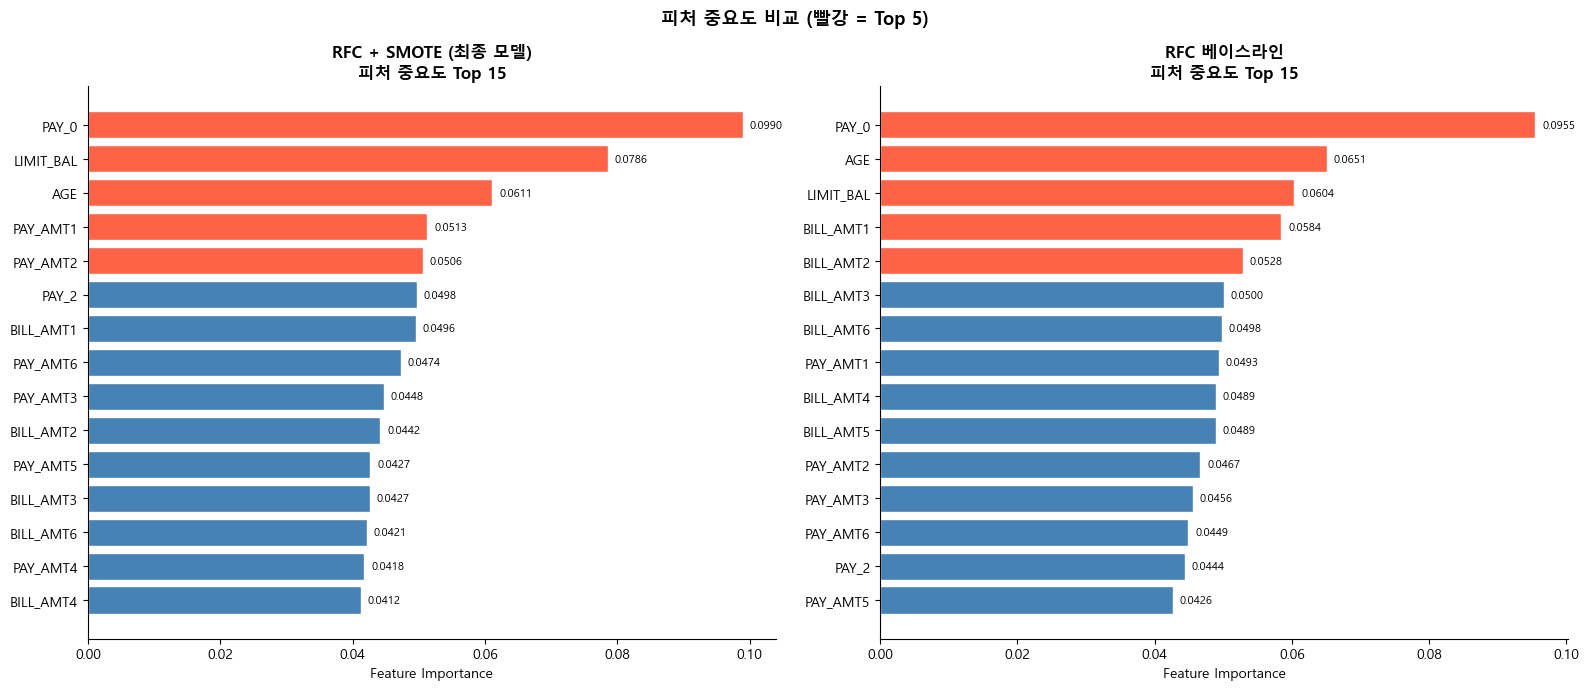

In [57]:
# ============================================================
# [추가 코드 4] 피처 중요도 비교 (RFC+SMOTE vs RFC 베이스라인)
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fi_smote = pd.Series(rfc_smote.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)
fi_base  = pd.Series(rfc_base.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)

print("=== RFC + SMOTE 피처 중요도 Top 10 ===")
print(fi_smote.head(10).round(4).to_string())
print("\n=== RFC 베이스라인 피처 중요도 Top 10 ===")
print(fi_base.head(10).round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top_n = 15

for ax, (fi, title) in zip(axes, [
    (fi_smote, 'RFC + SMOTE (최종 모델)'),
    (fi_base,  'RFC 베이스라인')
]):
    fi_top = fi.head(top_n)
    colors = ['tomato' if i < 5 else 'steelblue' for i in range(top_n)]
    ax.barh(fi_top.index[::-1], fi_top.values[::-1],
            color=colors[::-1], edgecolor='white')
    ax.set_title(f'{title}\n피처 중요도 Top {top_n}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    for i, val in enumerate(fi_top.values[::-1]):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('피처 중요도 비교 (빨강 = Top 5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


  PCA 분산 설명력 기준별 필요 PC 수
  80% 설명 : PC 9개  (누적 81.1%)
  90% 설명 : PC 13개  (누적 91.1%)
  95% 설명 : PC 16개  (누적 95.6%)


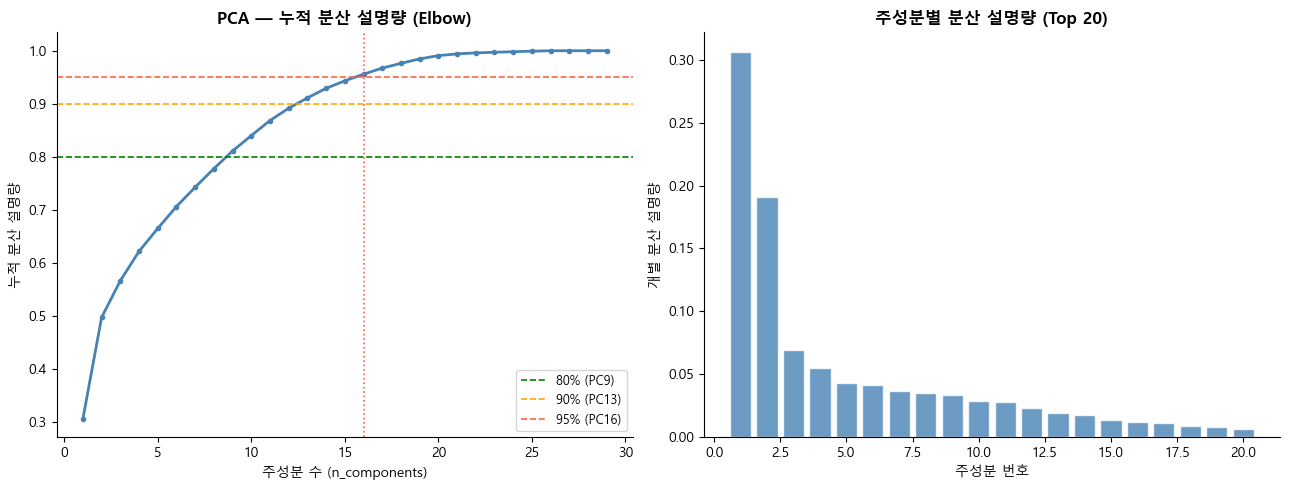

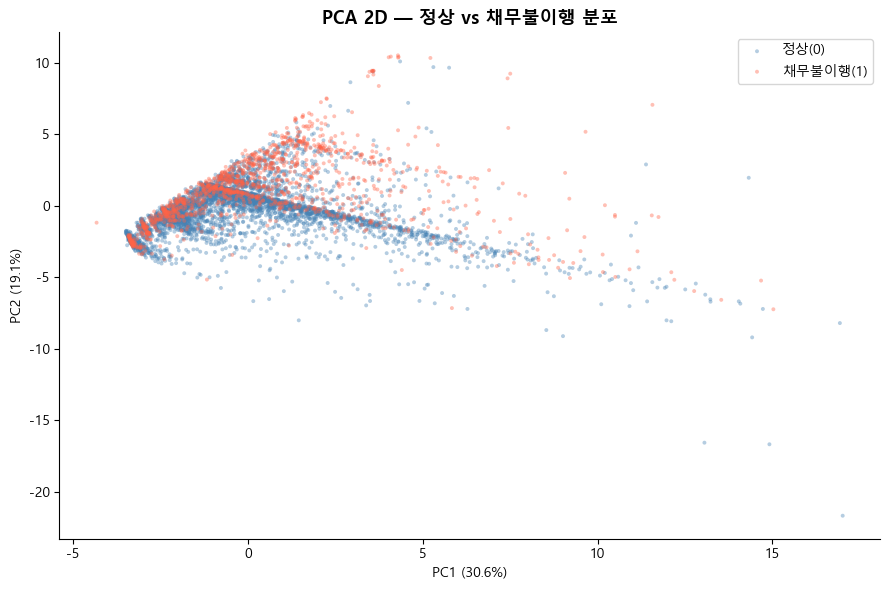

In [58]:
# ============================================================
# [추가 코드 5] PCA 분산 설명력 + Elbow Plot + 2D Scatter
# v11은 X_train이 이미 StandardScaler 적용 완료
# → StandardScaler 재적용 없이 PCA 바로 적용
# ============================================================
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 전체 성분 PCA로 분산 설명력 확인
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

explained  = pca_full.explained_variance_ratio_
cumsum_var = np.cumsum(explained)

n_80 = np.argmax(cumsum_var >= 0.80) + 1
n_90 = np.argmax(cumsum_var >= 0.90) + 1
n_95 = np.argmax(cumsum_var >= 0.95) + 1

print("=" * 50)
print("  PCA 분산 설명력 기준별 필요 PC 수")
print("=" * 50)
print(f"  80% 설명 : PC {n_80}개  (누적 {cumsum_var[n_80-1]*100:.1f}%)")
print(f"  90% 설명 : PC {n_90}개  (누적 {cumsum_var[n_90-1]*100:.1f}%)")
print(f"  95% 설명 : PC {n_95}개  (누적 {cumsum_var[n_95-1]*100:.1f}%)")

# ── Elbow Plot ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(range(1, len(cumsum_var)+1), cumsum_var,
         marker='o', markersize=3, color='steelblue', linewidth=2)
ax1.axhline(y=0.80, color='green',  linestyle='--', lw=1.2, label=f'80% (PC{n_80})')
ax1.axhline(y=0.90, color='orange', linestyle='--', lw=1.2, label=f'90% (PC{n_90})')
ax1.axhline(y=0.95, color='tomato', linestyle='--', lw=1.2, label=f'95% (PC{n_95})')
ax1.axvline(x=n_95, color='tomato', linestyle=':', lw=1.2)
ax1.set_xlabel('주성분 수 (n_components)')
ax1.set_ylabel('누적 분산 설명량')
ax1.set_title('PCA — 누적 분산 설명량 (Elbow)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

ax2.bar(range(1, 21), explained[:20],
        color='steelblue', edgecolor='white', alpha=0.8)
ax2.set_xlabel('주성분 번호')
ax2.set_ylabel('개별 분산 설명량')
ax2.set_title('주성분별 분산 설명량 (Top 20)', fontsize=12, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── 2D Scatter (PC1 vs PC2) 정상/불이행 분포 ──────────────
pca_2d   = PCA(n_components=2, random_state=42)
X_2d_tr  = pca_2d.fit_transform(X_train)
X_2d_te  = pca_2d.transform(X_test)

fig, ax = plt.subplots(figsize=(9, 6))
for label, color, name in [(0, 'steelblue', '정상(0)'), (1, 'tomato', '채무불이행(1)')]:
    mask = y_test == label
    ax.scatter(X_2d_te[mask, 0], X_2d_te[mask, 1],
               c=color, label=name, alpha=0.4, s=8, edgecolors='none')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA 2D — 정상 vs 채무불이행 분포', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


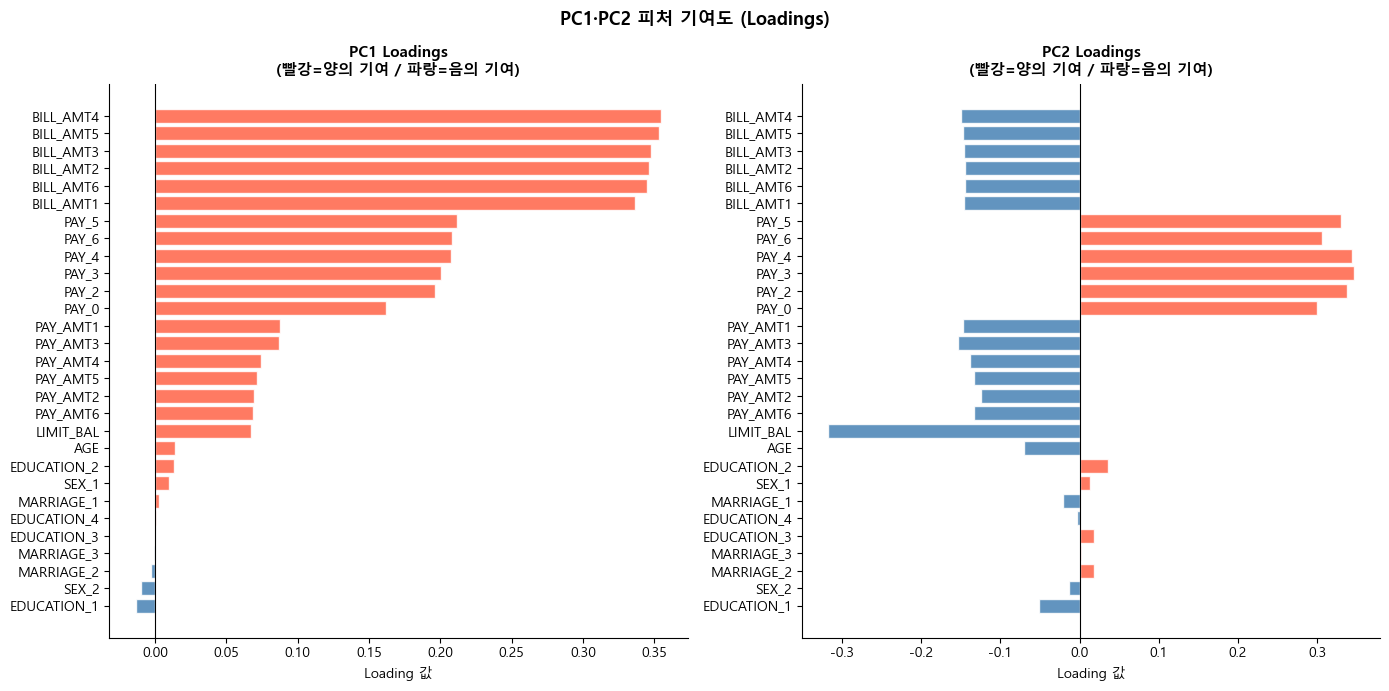

=== PC1 · PC2 Loadings 수치 ===
                PC1     PC2
EDUCATION_1 -0.0135 -0.0513
SEX_2       -0.0101 -0.0135
MARRIAGE_2  -0.0026  0.0185
MARRIAGE_3  -0.0005  0.0018
EDUCATION_3  0.0000  0.0183
EDUCATION_4  0.0003 -0.0029
MARRIAGE_1   0.0031 -0.0203
SEX_1        0.0101  0.0135
EDUCATION_2  0.0132  0.0360
AGE          0.0141 -0.0700
LIMIT_BAL    0.0671 -0.3174
PAY_AMT6     0.0689 -0.1332
PAY_AMT2     0.0695 -0.1240
PAY_AMT5     0.0712 -0.1328
PAY_AMT4     0.0742 -0.1386
PAY_AMT3     0.0868 -0.1532
PAY_AMT1     0.0877 -0.1469
PAY_0        0.1620  0.2995
PAY_2        0.1963  0.3384
PAY_3        0.2006  0.3463
PAY_4        0.2078  0.3438
PAY_6        0.2078  0.3061
PAY_5        0.2119  0.3308
BILL_AMT1    0.3361 -0.1457
BILL_AMT6    0.3445 -0.1443
BILL_AMT2    0.3463 -0.1450
BILL_AMT3    0.3480 -0.1458
BILL_AMT5    0.3529 -0.1474
BILL_AMT4    0.3548 -0.1501


In [59]:
# ============================================================
# [추가 코드 6] PCA Loadings 분석 (PC1·PC2)
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# pca_full 은 코드5에서 이미 fit 완료
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=X_train.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, col in zip(axes, ['PC1', 'PC2']):
    colors = ['tomato' if v > 0 else 'steelblue' for v in loadings[col]]
    ax.barh(loadings.index, loadings[col],
            color=colors, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{col} Loadings\n(빨강=양의 기여 / 파랑=음의 기여)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Loading 값')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('PC1·PC2 피처 기여도 (Loadings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== PC1 · PC2 Loadings 수치 ===")
print(loadings.round(4).to_string())


In [60]:
# ============================================================
# [추가 코드 7] PCA-C(PC15) + 3모델 학습 및 비교
# v11은 X_train이 이미 StandardScaler 적용 → 바로 PCA 적용
# ============================================================
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (recall_score, f1_score, roc_auc_score,
                             precision_score, classification_report)
import pandas as pd

N_COMPONENTS = 15   # 95% 분산 설명 기준

pca_c = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_c = pca_c.fit_transform(X_train)
X_test_c  = pca_c.transform(X_test)

print(f"PCA-C 변환 후  — train: {X_train_c.shape}, test: {X_test_c.shape}")
print(f"누적 분산 설명력 : {pca_c.explained_variance_ratio_.sum()*100:.1f}%")

# SMOTE는 PCA 변환 후 train에만 적용
X_train_c_smote, y_train_c_smote = SMOTE(random_state=42).fit_resample(
    X_train_c, y_train
)
print(f"SMOTE 후 train : {X_train_c_smote.shape}")

# 3개 모델 정의
models_c = {
    'RFC + PCA-C':          (RandomForestClassifier(n_estimators=100, random_state=42),
                             X_train_c,       y_train),
    'RFC + SMOTE + PCA-C':  (RandomForestClassifier(n_estimators=100, random_state=42),
                             X_train_c_smote, y_train_c_smote),
    'XGBoost + PCA-C':      (XGBClassifier(n_estimators=100, random_state=42,
                                           eval_metric='logloss',
                                           use_label_encoder=False),
                             X_train_c,       y_train),
}

rows_c = []
for name, (model, Xtr, ytr) in models_c.items():
    model.fit(Xtr, ytr)
    yp    = model.predict(X_test_c)
    yprob = model.predict_proba(X_test_c)[:, 1]
    rows_c.append({
        '모델':      name,
        'Precision': round(precision_score(y_test, yp, pos_label=1), 4),
        'Recall':    round(recall_score(y_test, yp, pos_label=1),    4),
        'F1-Score':  round(f1_score(y_test, yp, pos_label=1),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, yprob),             4),
    })
    print(f"=== {name} ===")
    print(classification_report(y_test, yp, target_names=['정상(0)', '채무불이행(1)']))
    print(f"ROC-AUC : {rows_c[-1]['ROC-AUC']}\n")

compare_pca = pd.DataFrame(rows_c).set_index('모델')
print("=" * 60)
print("  PCA-C(PC15) 모델 성능 비교")
print("=" * 60)
print(compare_pca.to_string())


PCA-C 변환 후  — train: (24000, 15), test: (6000, 15)
누적 분산 설명력 : 94.3%
SMOTE 후 train : (37382, 15)
=== RFC + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.64      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7459

=== RFC + SMOTE + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7462

=== XGBoost + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.93      0.88      4673
    채무불이행(1)       0.59      0.3

  최종 모델 성능 — RFC + SMOTE + PCA-C(PC15)
              precision    recall  f1-score   support

       정상(0)       0.85      0.87      0.86      4673
    채무불이행(1)       0.51      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC          : 0.7462
Average Precision : 0.4976

TN=4,057  FP=616  FN=693  TP=634
Recall(탐지율) = 0.4778  |  실제 불이행 1,327명 중 634명 탐지


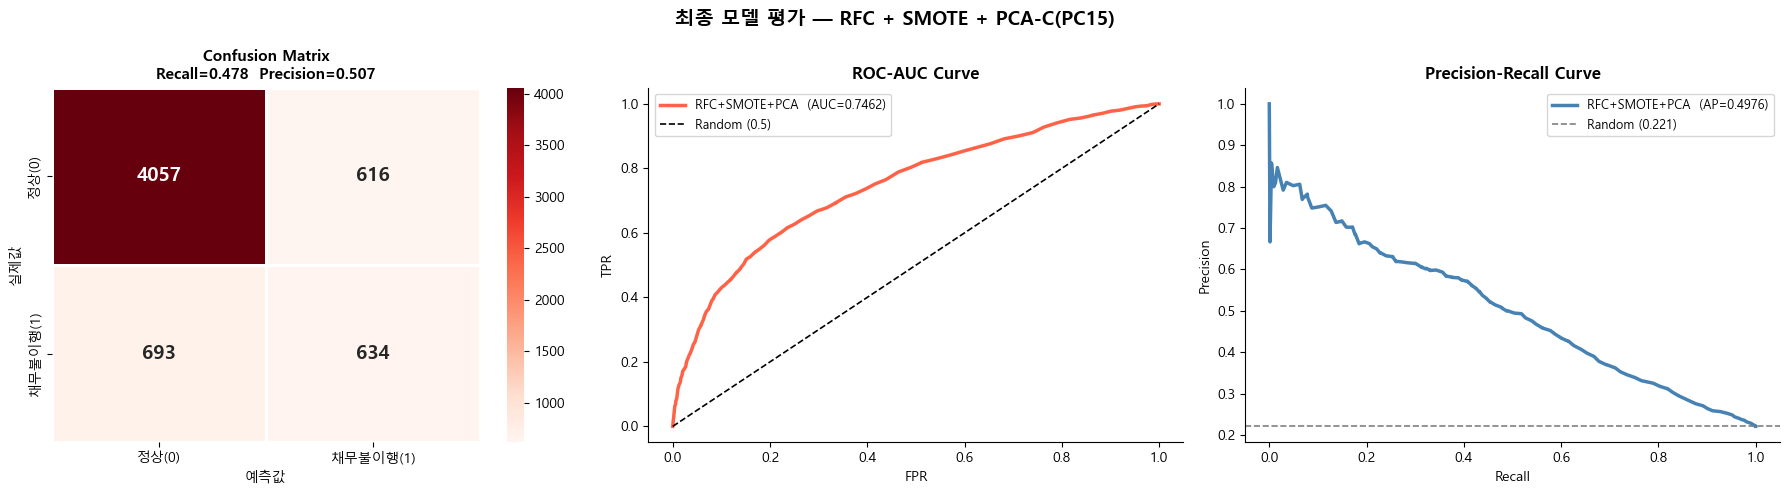


  ✅ RFC + SMOTE + PCA-C(PC15) 최종 평가 완료


In [61]:
# ============================================================
# [추가 코드 8] 최종 모델 평가 — RFC + SMOTE + PCA-C(PC15)
# models_c 딕셔너리에서 최종 모델 추출
# ============================================================
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 최종 모델 (코드7에서 학습 완료)
final_model = models_c['RFC + SMOTE + PCA-C'][0]
yp_final    = final_model.predict(X_test_c)
yprob_final = final_model.predict_proba(X_test_c)[:, 1]

# ── 1. Classification Report ─────────────────────────────────
print("=" * 60)
print("  최종 모델 성능 — RFC + SMOTE + PCA-C(PC15)")
print("=" * 60)
print(classification_report(y_test, yp_final,
      target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC          : {roc_auc_score(y_test, yprob_final):.4f}")
print(f"Average Precision : {average_precision_score(y_test, yprob_final):.4f}")

# ── 2. Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, yp_final)
tn, fp, fn, tp = cm.ravel()
print(f"\nTN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Recall(탐지율) = {tp/(tp+fn):.4f}  |  "
      f"실제 불이행 {tp+fn:,}명 중 {tp:,}명 탐지")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('최종 모델 평가 — RFC + SMOTE + PCA-C(PC15)',
             fontsize=14, fontweight='bold')

# Confusion Matrix 히트맵
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            linewidths=1, linecolor='white',
            xticklabels=['정상(0)', '채무불이행(1)'],
            yticklabels=['정상(0)', '채무불이행(1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix\nRecall={tp/(tp+fn):.3f}  Precision={tp/(tp+fp):.3f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('예측값'); axes[0].set_ylabel('실제값')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, yprob_final)
auc_val = roc_auc_score(y_test, yprob_final)
axes[1].plot(fpr, tpr, color='tomato', lw=2.5,
             label=f'RFC+SMOTE+PCA  (AUC={auc_val:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.2, label='Random (0.5)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC-AUC Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

# Precision-Recall Curve
prec_c, rec_c, _ = precision_recall_curve(y_test, yprob_final)
ap_val = average_precision_score(y_test, yprob_final)
axes[2].plot(rec_c, prec_c, color='steelblue', lw=2.5,
             label=f'RFC+SMOTE+PCA  (AP={ap_val:.4f})')
axes[2].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1.2,
                label=f'Random ({y_test.mean():.3f})')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("  ✅ RFC + SMOTE + PCA-C(PC15) 최종 평가 완료")
print("=" * 60)


# END